# Praprocess Data Housing Price

## Mengimpor Library Penting

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## Memuat Dataset

In [35]:
path = "train.csv"

data         = pd.read_csv(path).drop(columns=["Id"])
num_data     = data.select_dtypes(["float64", "int64"])
nominal_data = data.select_dtypes(["str"])
data.info()

for col in data.columns:
    print(f"\nFirst 10 unique values for {col} column:")
    print(data[col].unique()[:10].tolist())

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

## Melihat Distribusi Fitur Numerik (Mentah)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroo

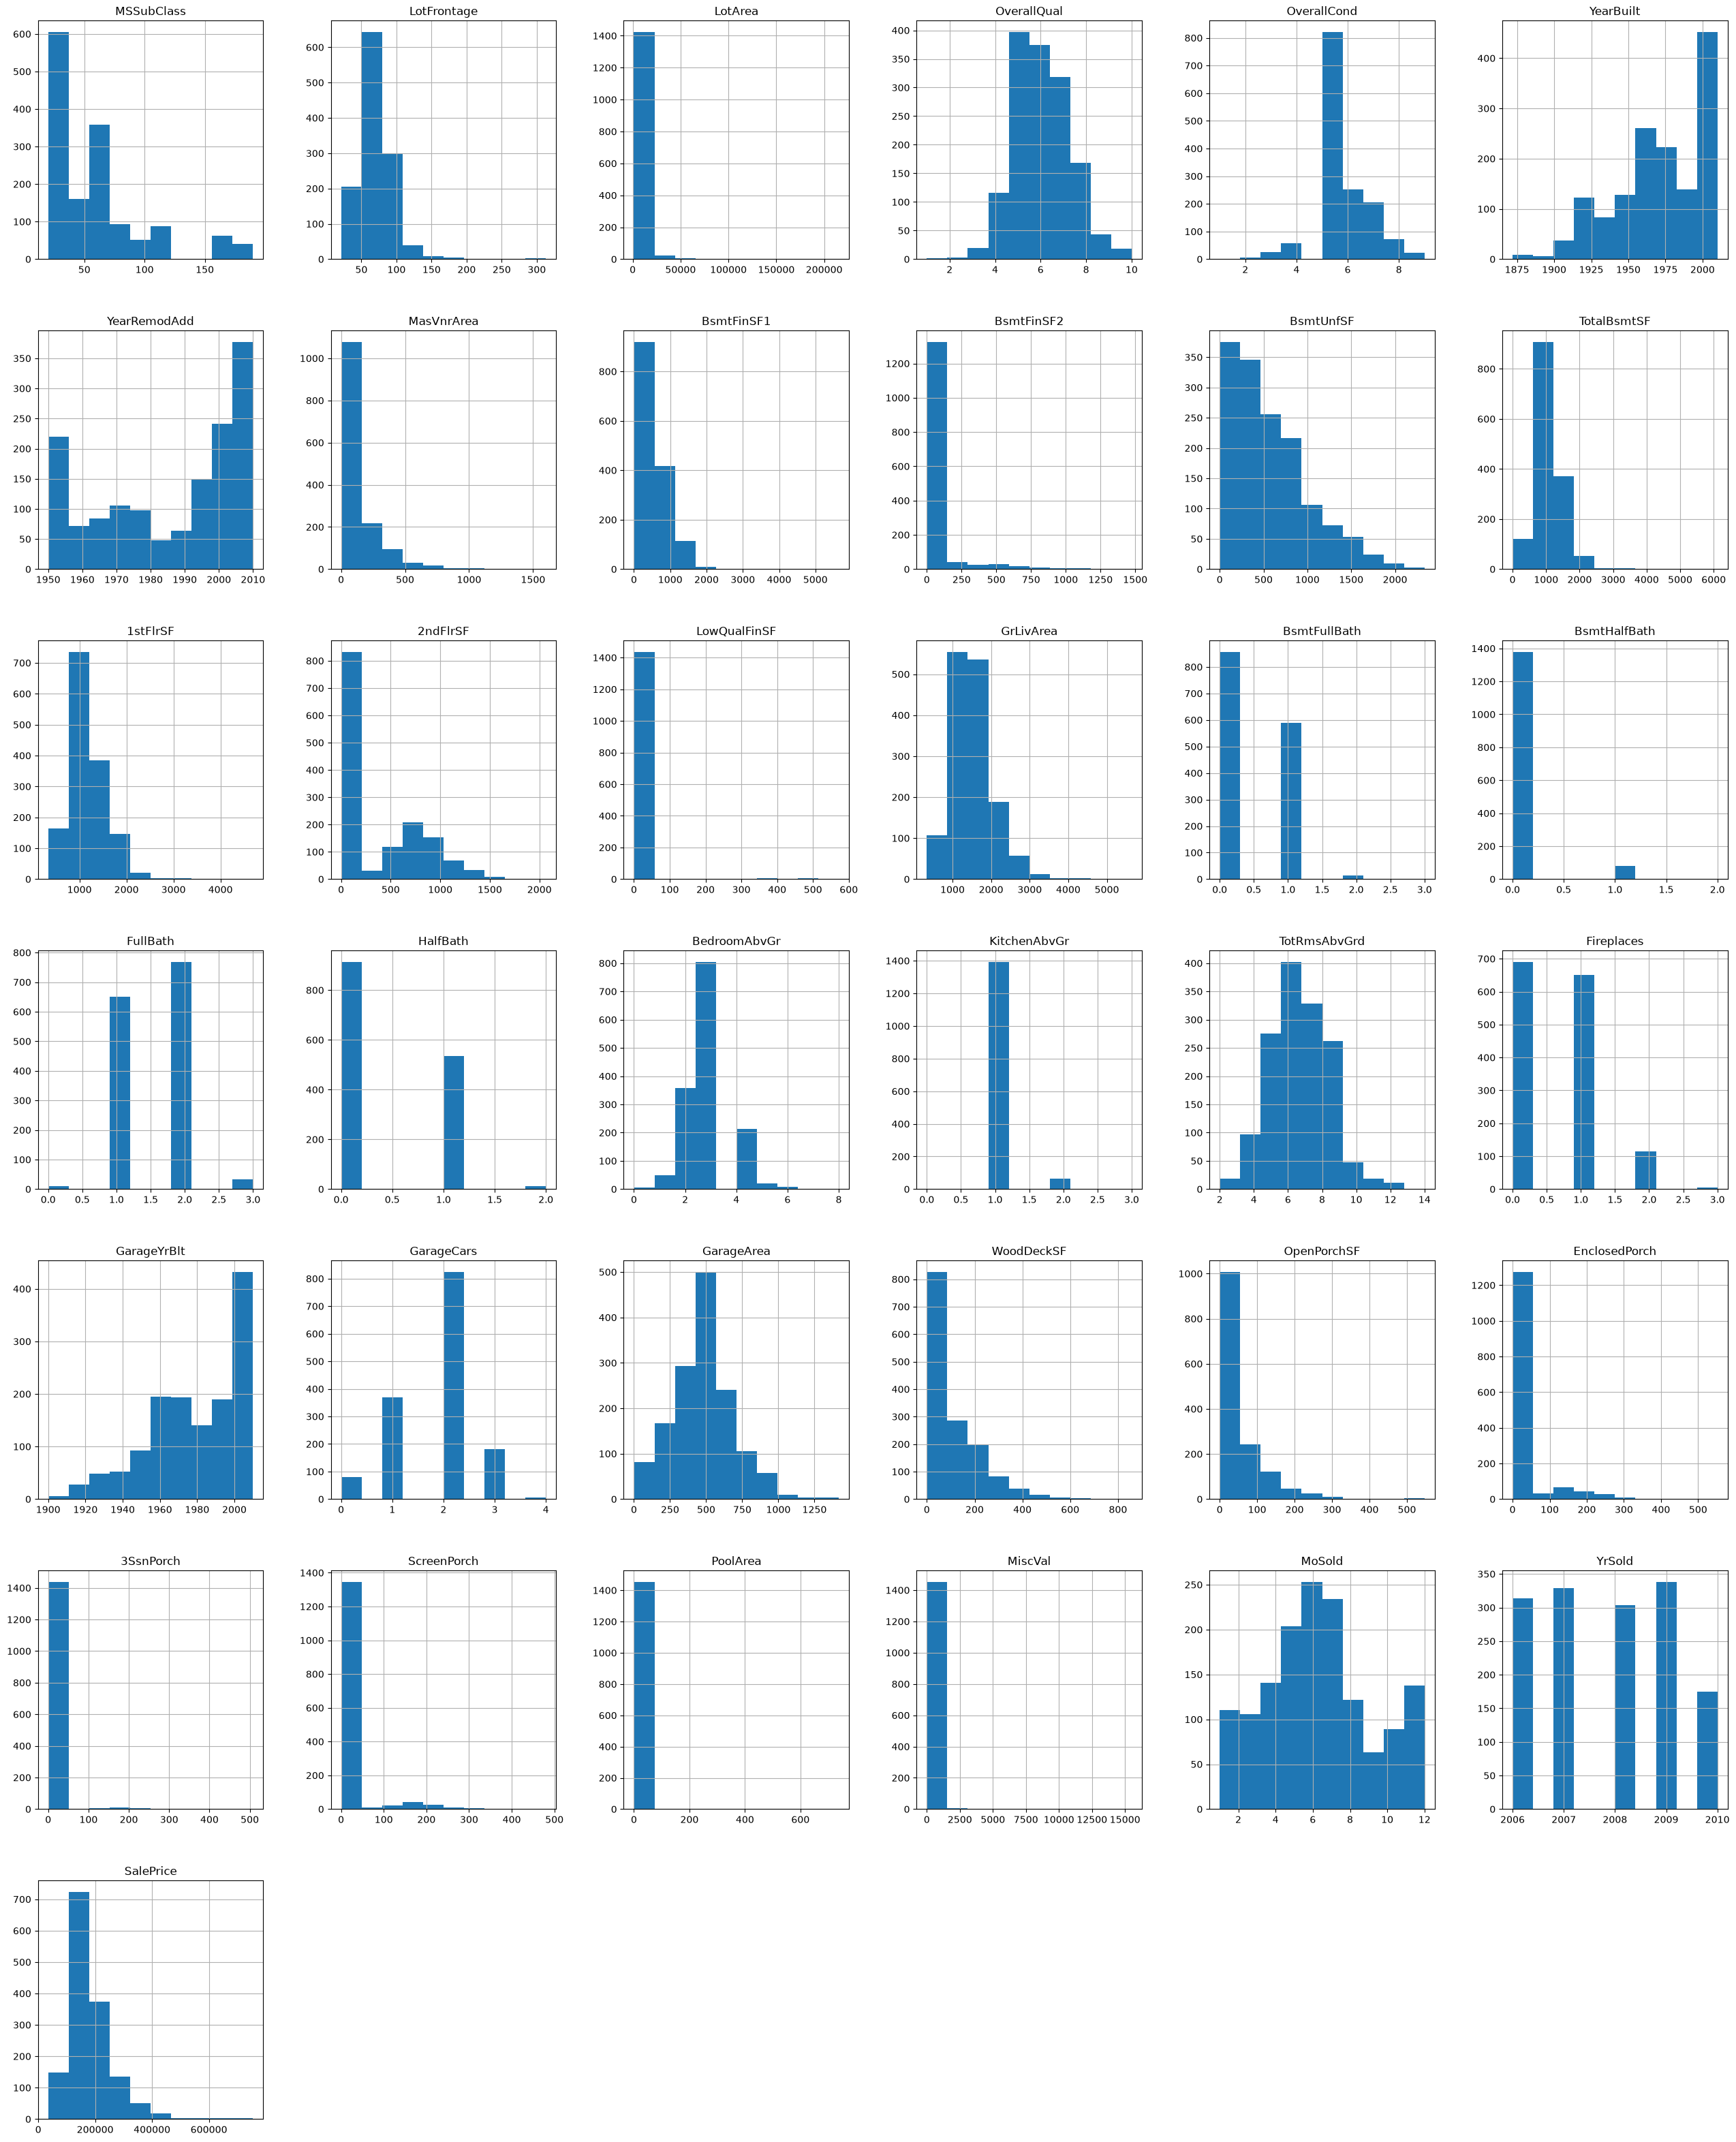

In [36]:
display(num_data.describe())

num_data.hist(figsize=(32, 40))

## Melihat Distribusi Fitur Kategorikal (Mentah)

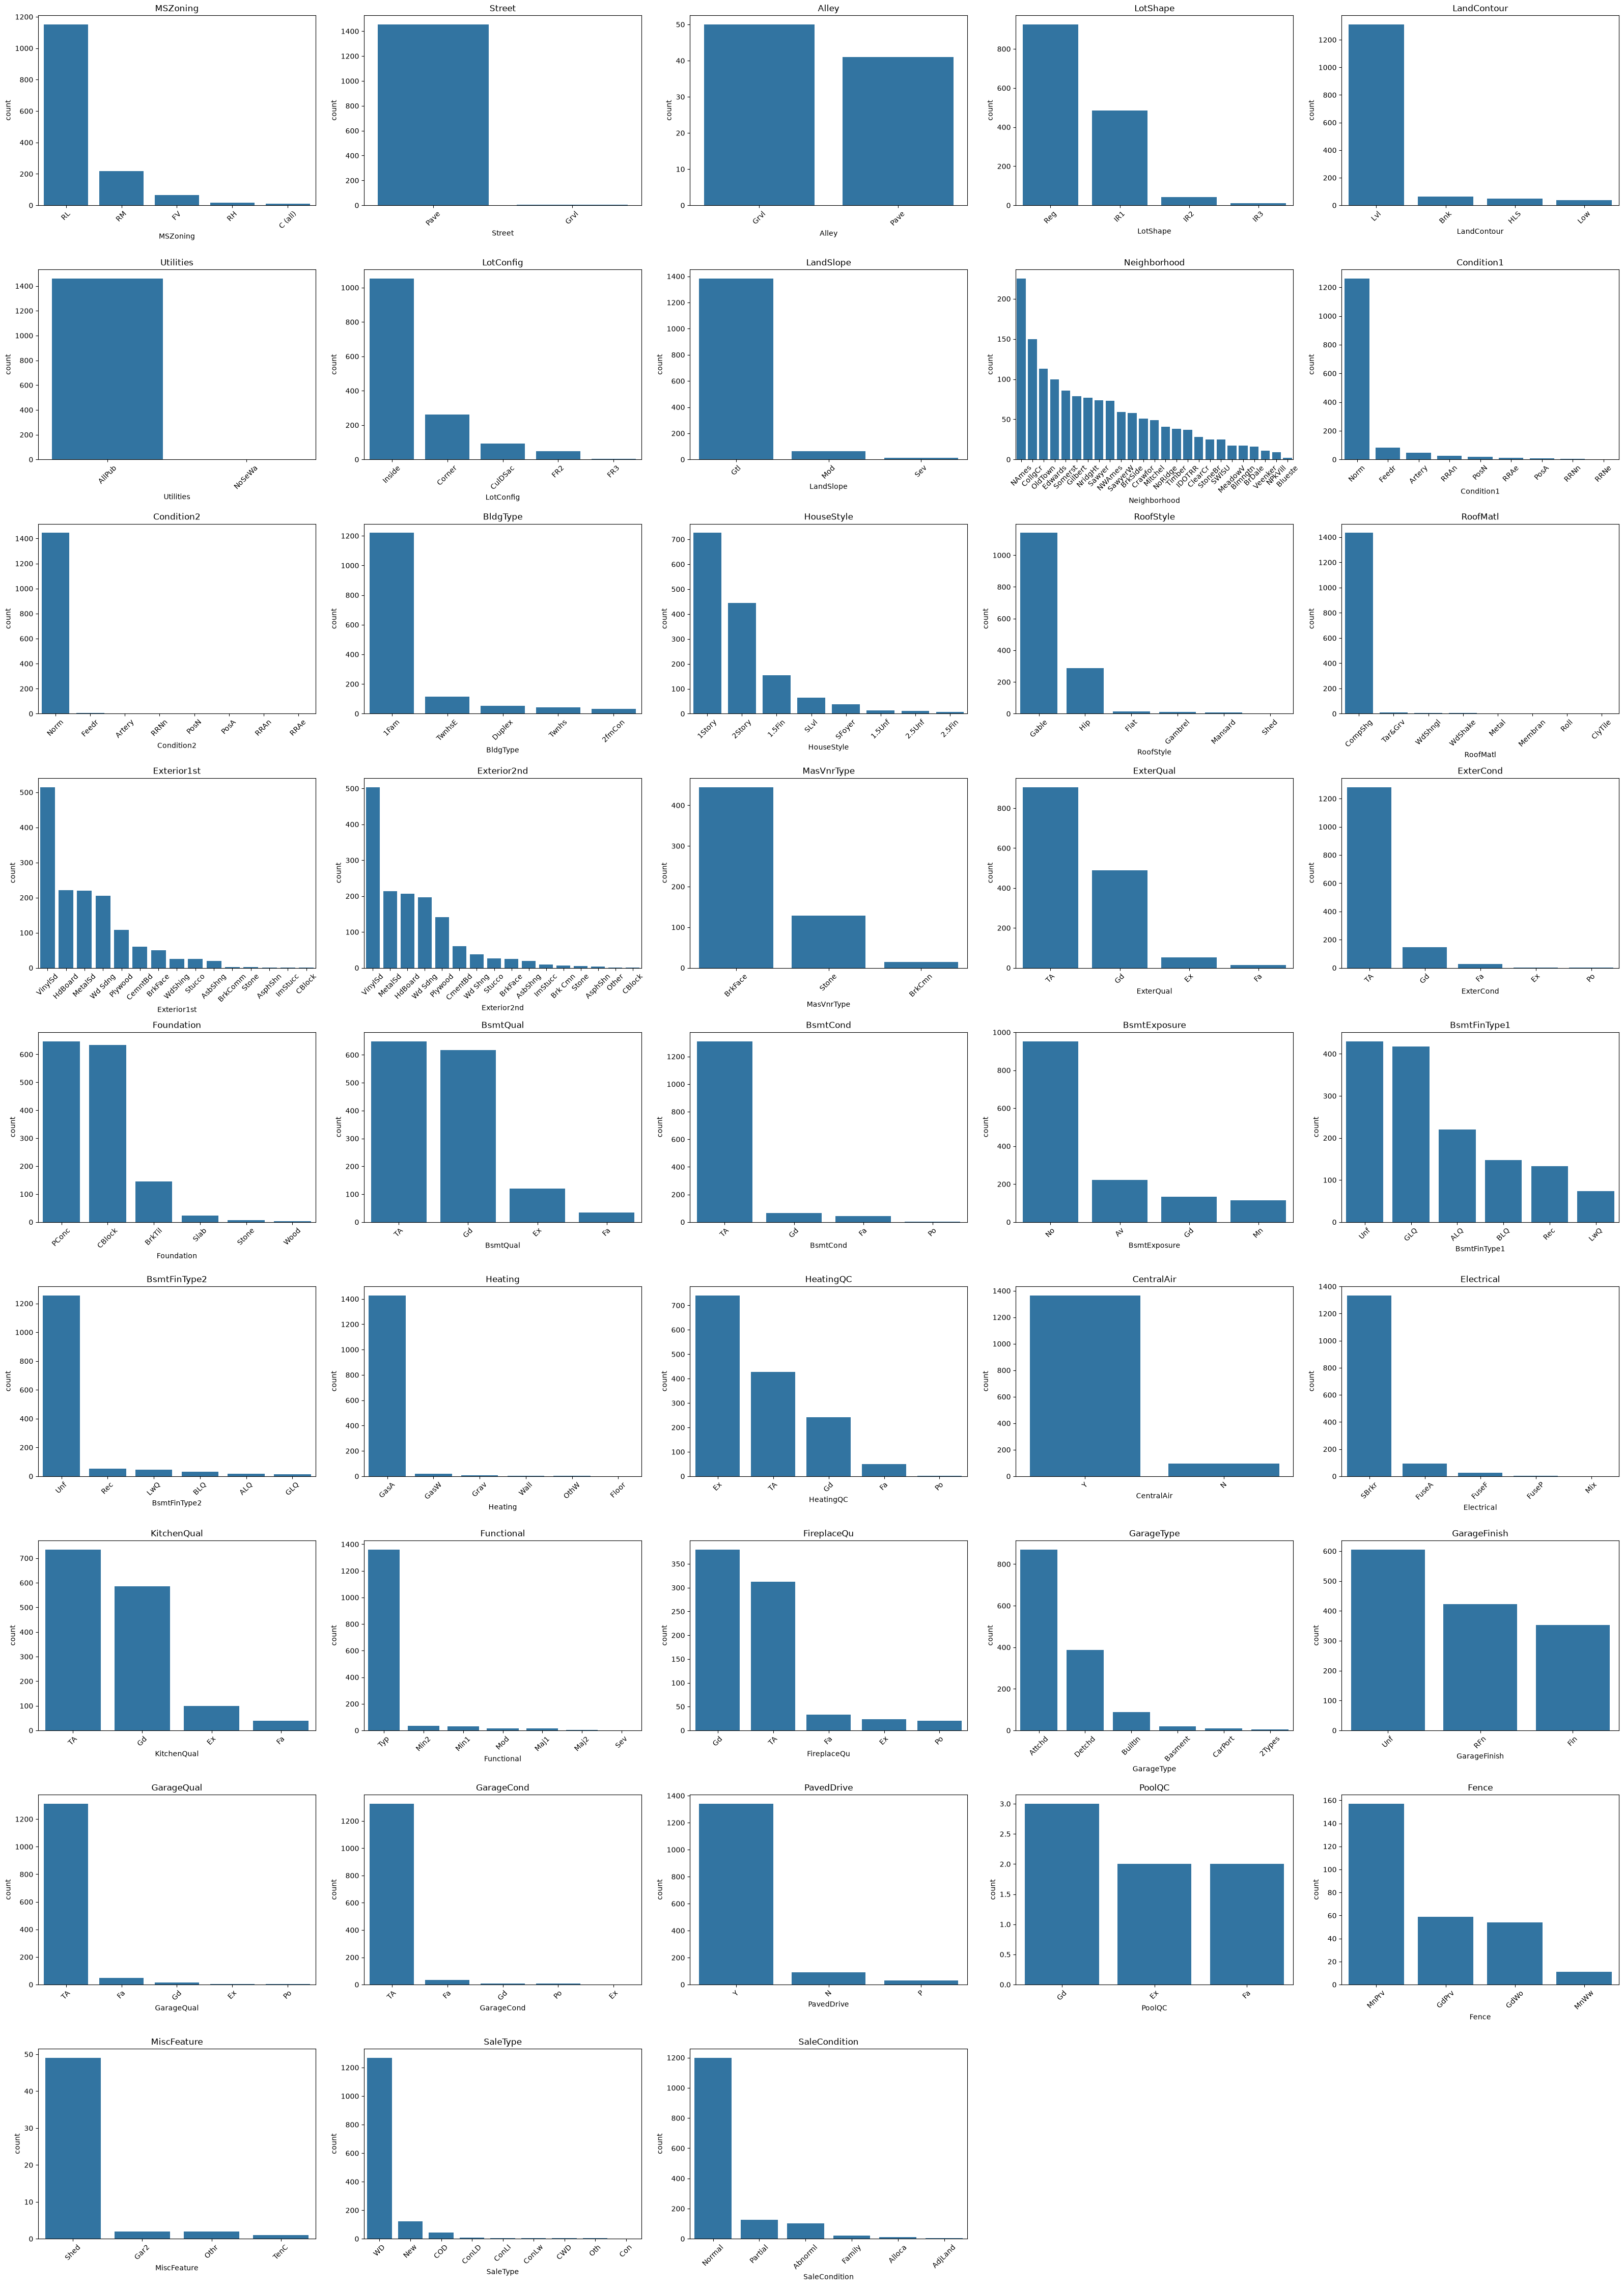

In [37]:
nrows, ncols = 9, 5
cols         = nominal_data.columns
fig, ax      = plt.subplots(nrows=nrows, ncols=ncols, figsize=(32, 45))

for i in range(nrows):
    for j in range(ncols):
        idx = i * ncols + j
        if idx < len(cols):
            col = cols[idx]
            order = nominal_data[col].value_counts().index
            sns.countplot(data=nominal_data, x=col, order=order, ax=ax[i, j])
            ax[i, j].set_title(col)
            ax[i, j].tick_params(axis="x", rotation=45)
        else:
            ax[i, j].axis("off")

plt.tight_layout()
plt.show()

## Menangani Nilai Hilang (Missing Values)

### Melihat Proporsi Nilai Hilang pada Tiap Fitur

,Jumlah Nilai Hilang,Proporsi Nilai Hilang (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


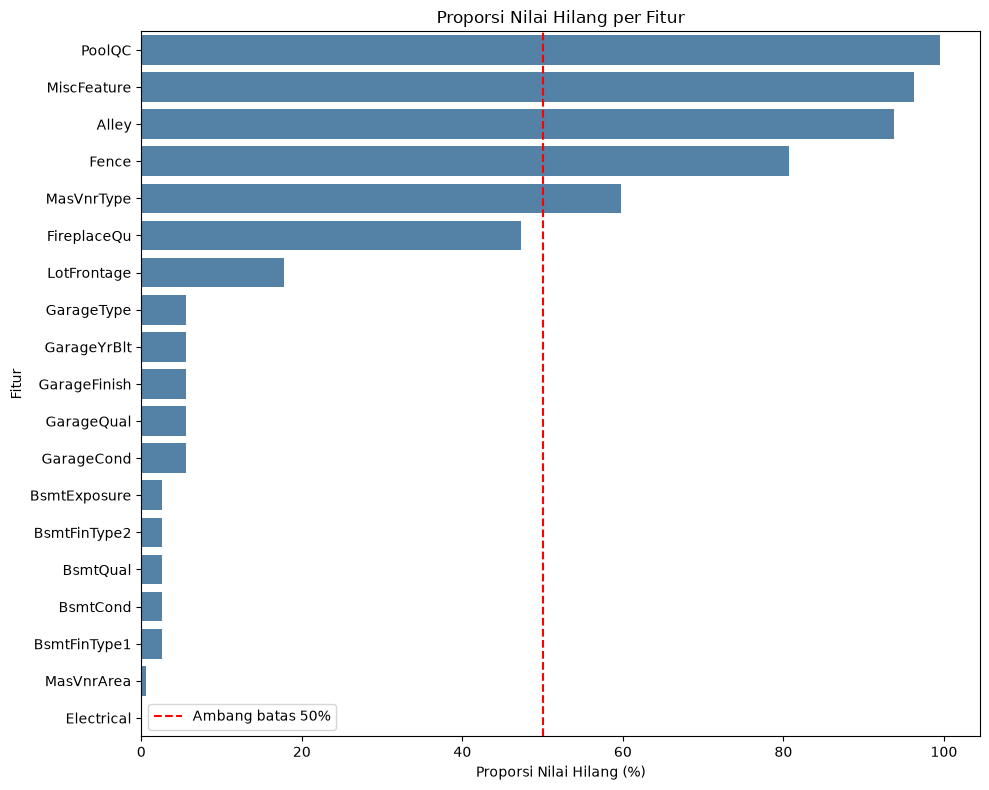

In [38]:
missing_count = data.isnull().sum()
missing_pct   = (missing_count / len(data) * 100).round(2)

missing_df = pd.DataFrame({
    "Jumlah Nilai Hilang": missing_count,
    "Proporsi Nilai Hilang (%)": missing_pct
})
missing_df = missing_df[missing_df["Jumlah Nilai Hilang"] > 0].sort_values(
    "Proporsi Nilai Hilang (%)", ascending=False
)

display(missing_df)

plt.figure(figsize=(10, 8))
sns.barplot(x=missing_df["Proporsi Nilai Hilang (%)"], y=missing_df.index, color="steelblue")
plt.axvline(50, color="red", linestyle="--", label="Ambang batas 50%")
plt.title("Proporsi Nilai Hilang per Fitur")
plt.xlabel("Proporsi Nilai Hilang (%)")
plt.ylabel("Fitur")
plt.legend()
plt.tight_layout()
plt.show()

### Menghapus Fitur dengan Proporsi Nilai Hilang >= 50%

Fitur yang kehilangan setengah atau lebih datanya umumnya sudah tidak cukup informatif untuk diisi (imputasi) karena terlalu banyak nilai yang harus ditebak, sehingga lebih aman untuk dihapus langsung.

In [39]:
drop_threshold = 50  # dalam persen

cols_to_drop_missing = missing_df[missing_df["Proporsi Nilai Hilang (%)"] >= drop_threshold].index.tolist()
print(f"Fitur yang dihapus (proporsi nilai hilang >= {drop_threshold}%):")
print(cols_to_drop_missing)

print(f"\nUkuran data sebelum penghapusan fitur: {data.shape}")
data = data.drop(columns=cols_to_drop_missing)
print(f"Ukuran data setelah penghapusan fitur : {data.shape}")

# Perbarui referensi subset numerik & kategorikal
num_data     = data.select_dtypes(["float64", "int64"])
nominal_data = data.select_dtypes(["str"])

Fitur yang dihapus (proporsi nilai hilang >= 50%):
['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']

Ukuran data sebelum penghapusan fitur: (1460, 80)
Ukuran data setelah penghapusan fitur : (1460, 75)


### Menangani Fitur dengan Proporsi Nilai Hilang < 50%

Untuk fitur yang masih memiliki nilai hilang namun proporsinya di bawah 50%, tersedia tiga opsi strategi penanganan yang dapat dipilih melalui variabel `missing_strategy`:

- **`"mode"`** — mengisi nilai hilang dengan nilai modus (nilai yang paling sering muncul) pada masing-masing kolom.
- **`"category"`** — membuat kategori/nilai baru sebagai penanda bahwa data tersebut memang hilang (`"Missing"` untuk kategorikal, `-1` untuk numerik).
- **`"drop_rows"`** — menghapus seluruh baris yang memiliki nilai hilang pada fitur-fitur ini.

Ganti nilai `missing_strategy` di bawah untuk mencoba masing-masing opsi.

In [40]:
missing_strategy = "mode"  # pilihan: "mode", "category", atau "drop_rows"

cols_with_missing = data.columns[data.isnull().any()].tolist()
print("Fitur dengan nilai hilang (< {}%) yang perlu ditangani:".format(drop_threshold))
print(cols_with_missing)

Fitur dengan nilai hilang (< 50%) yang perlu ditangani:
['LotFrontage', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']


In [41]:
if missing_strategy == "mode":
    for col in cols_with_missing:
        data[col] = data[col].fillna(data[col].mode()[0])
    print("Nilai hilang telah diisi menggunakan modus tiap kolom.")

elif missing_strategy == "category":
    for col in cols_with_missing:
        if data[col].dtype in ["float64", "int64"]:
            data[col] = data[col].fillna(0)
        else:
            data[col] = data[col].fillna("Missing")
    print("Nilai hilang telah diisi dengan kategori/nilai baru penanda missing.")

elif missing_strategy == "drop_rows":
    print(f"Ukuran data sebelum penghapusan baris: {data.shape}")
    data = data.dropna(subset=cols_with_missing).reset_index(drop=True)
    print(f"Ukuran data setelah penghapusan baris: {data.shape}")

else:
    raise ValueError('missing_strategy harus salah satu dari: "mode", "category", "drop_rows"')

print(f"\nTotal nilai hilang yang tersisa di seluruh data: {data.isnull().sum().sum()}")

# Perbarui referensi subset numerik & kategorikal
num_data     = data.select_dtypes(["float64", "int64"])
nominal_data = data.select_dtypes(["str"])

Nilai hilang telah diisi menggunakan modus tiap kolom.

Total nilai hilang yang tersisa di seluruh data: 0


### Menampilkan Distribusi Atribut Setelah Penanganan Data Hilang

array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroo

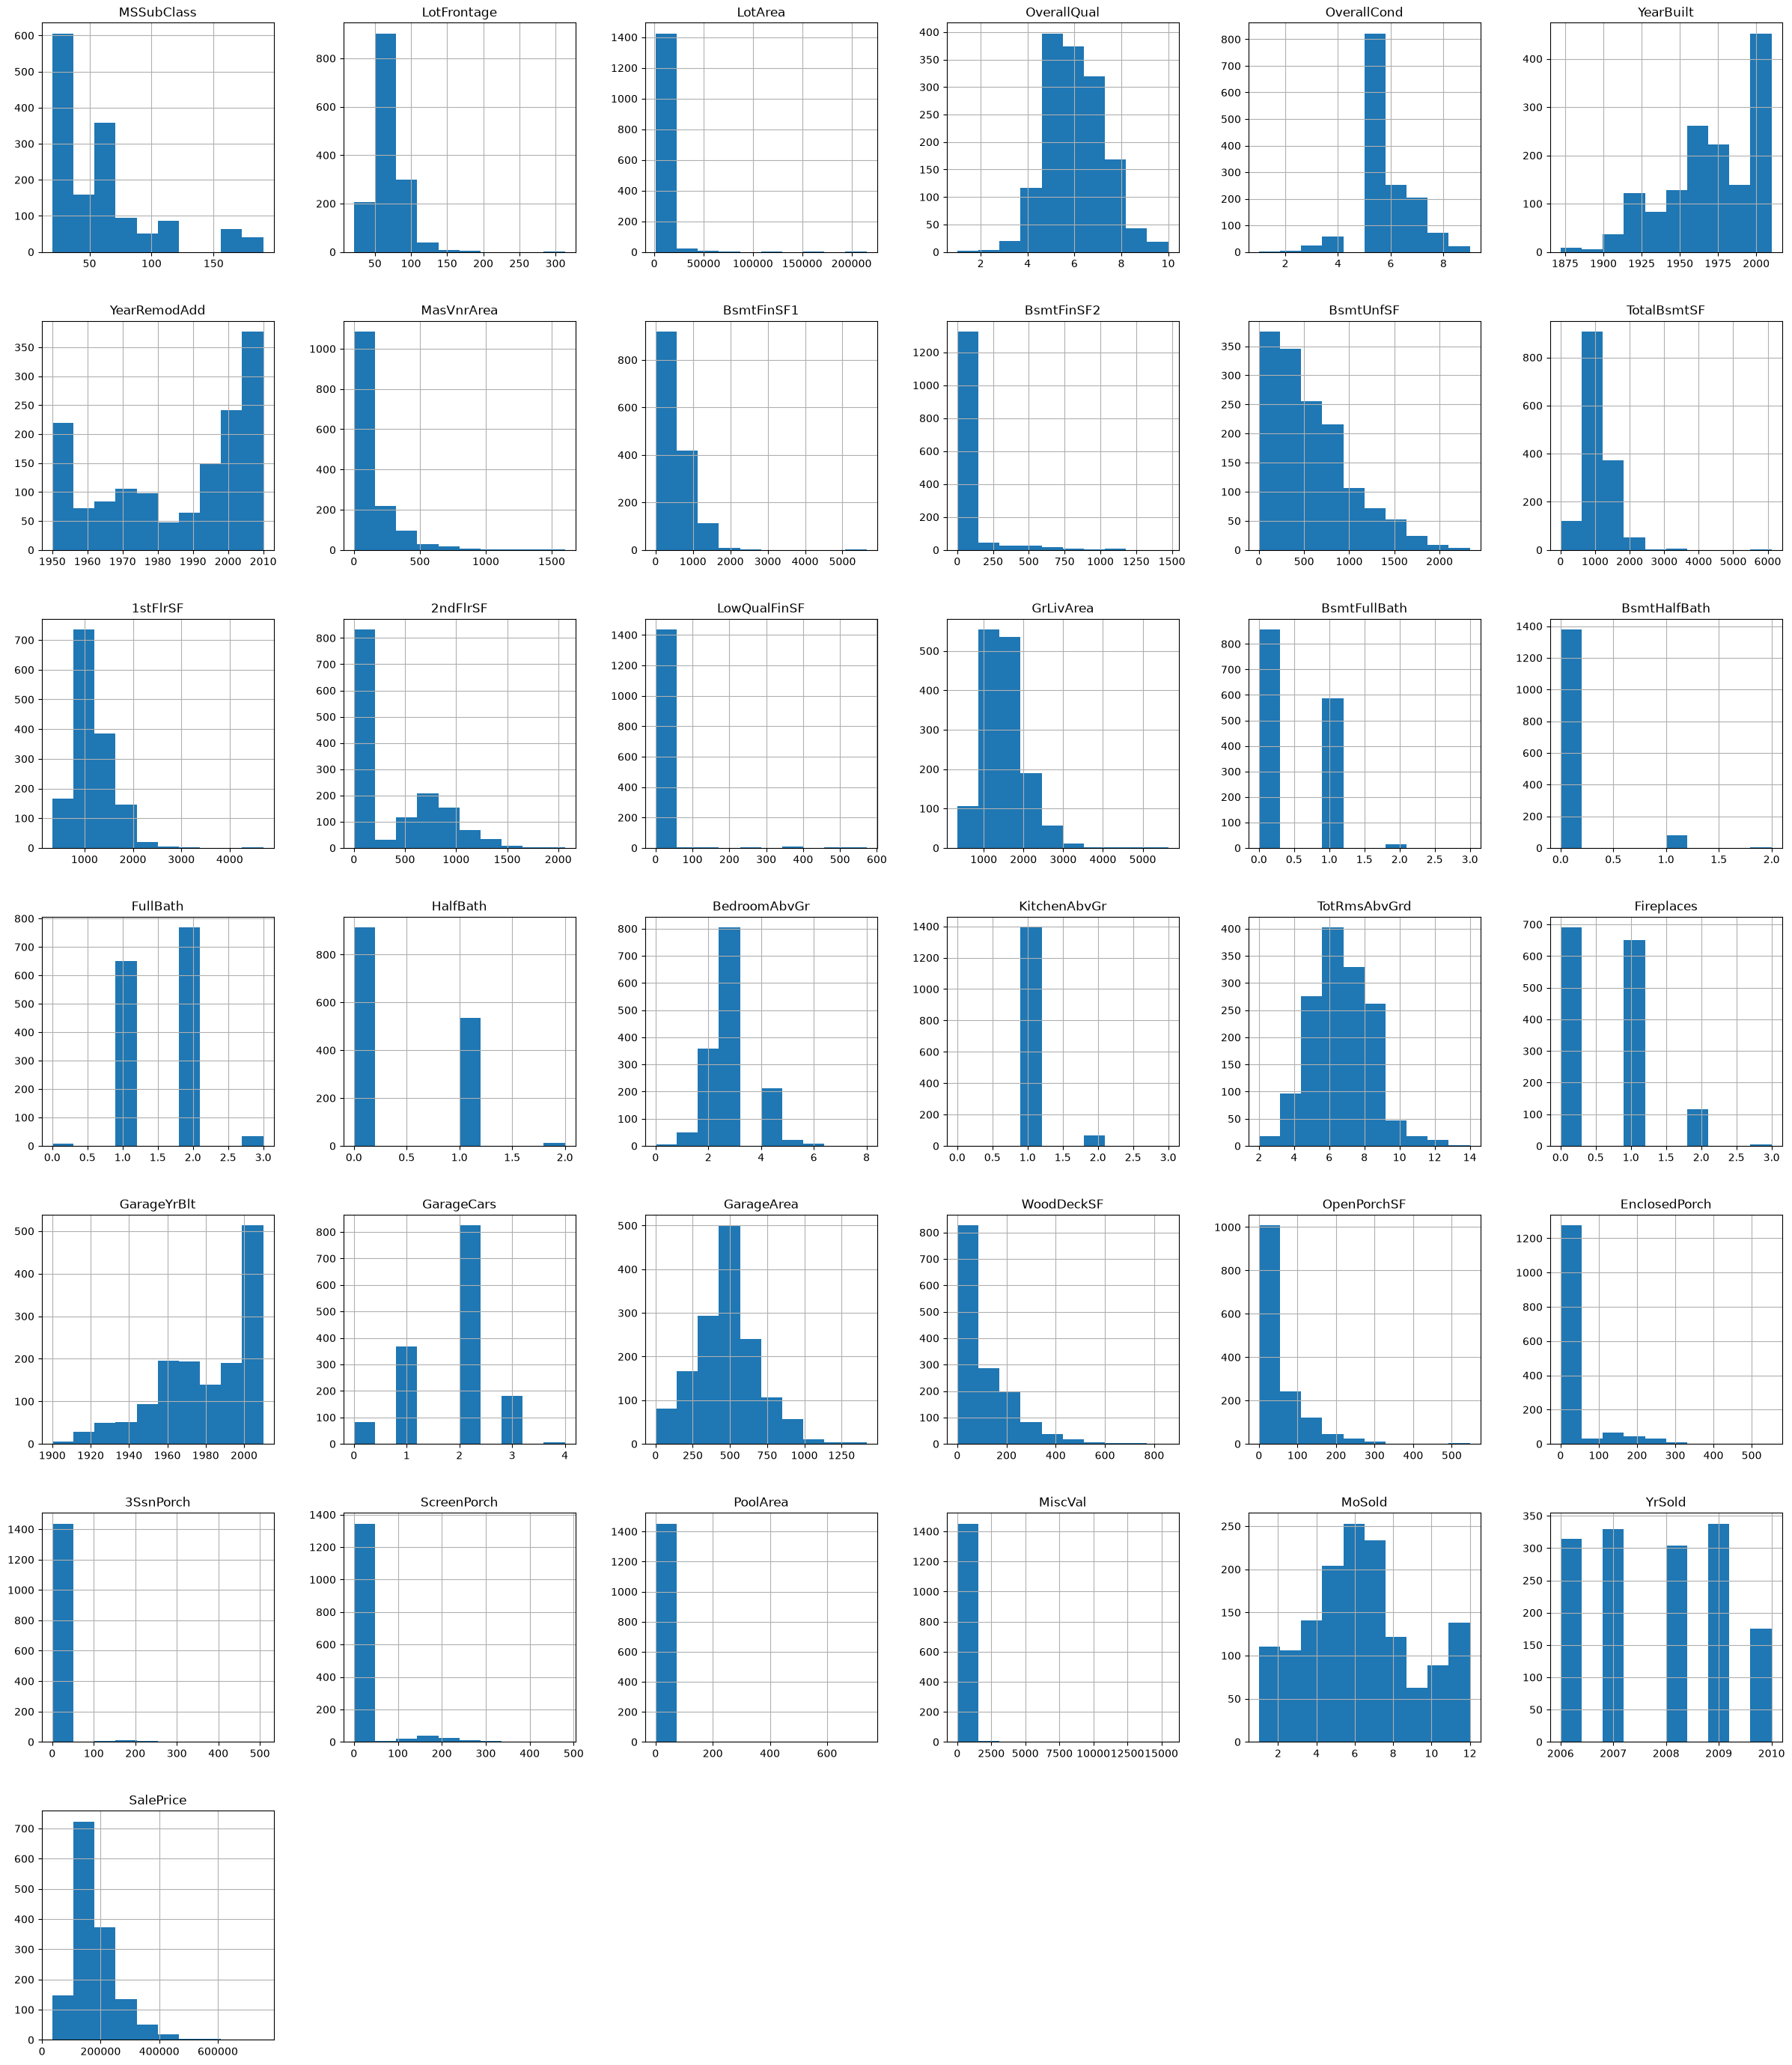

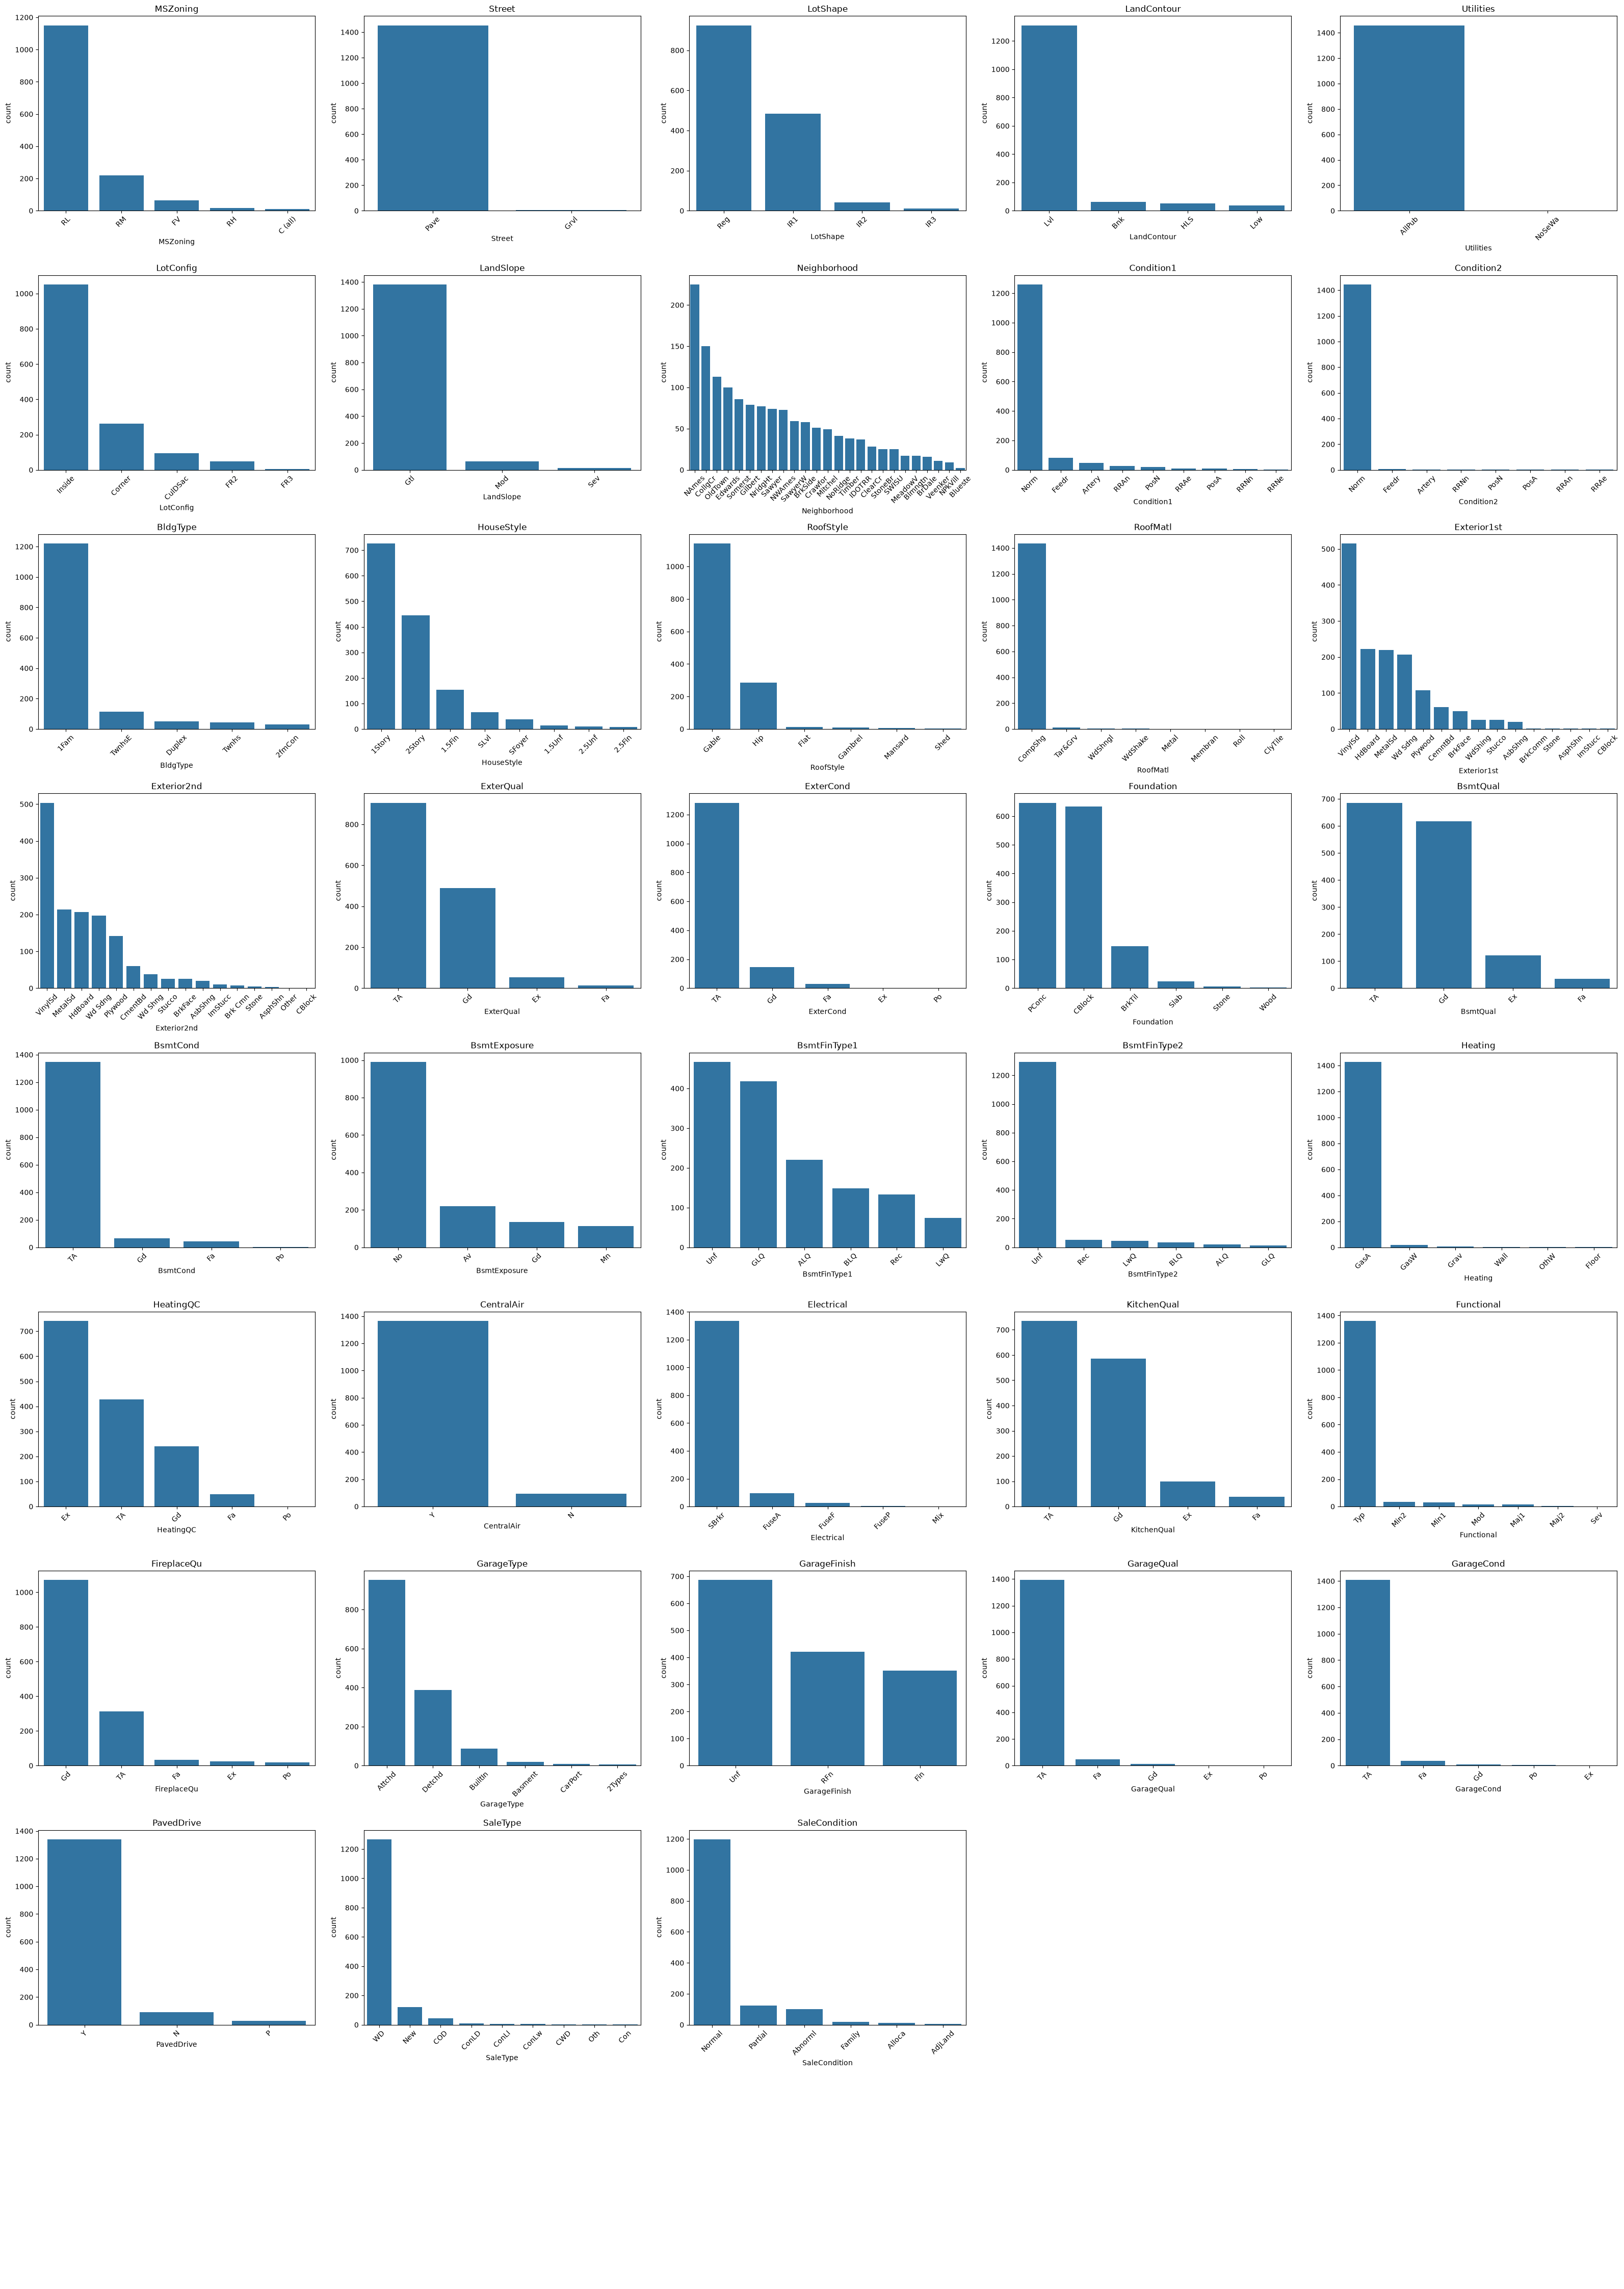

In [42]:
display(num_data.hist(figsize=(30, 35)))

nrows, ncols = 9, 5
cols         = nominal_data.columns
fig, ax      = plt.subplots(nrows=nrows, ncols=ncols, figsize=(32, 45))

for i in range(nrows):
    for j in range(ncols):
        idx = i * ncols + j
        if idx < len(cols):
            col = cols[idx]
            order = nominal_data[col].value_counts().index
            sns.countplot(data=nominal_data, x=col, order=order, ax=ax[i, j])
            ax[i, j].set_title(col)
            ax[i, j].tick_params(axis="x", rotation=45)
        else:
            ax[i, j].axis("off")

plt.tight_layout()
plt.show()

## Deteksi dan Penanganan Outlier

### Visualisasi Outlier dengan Boxplot

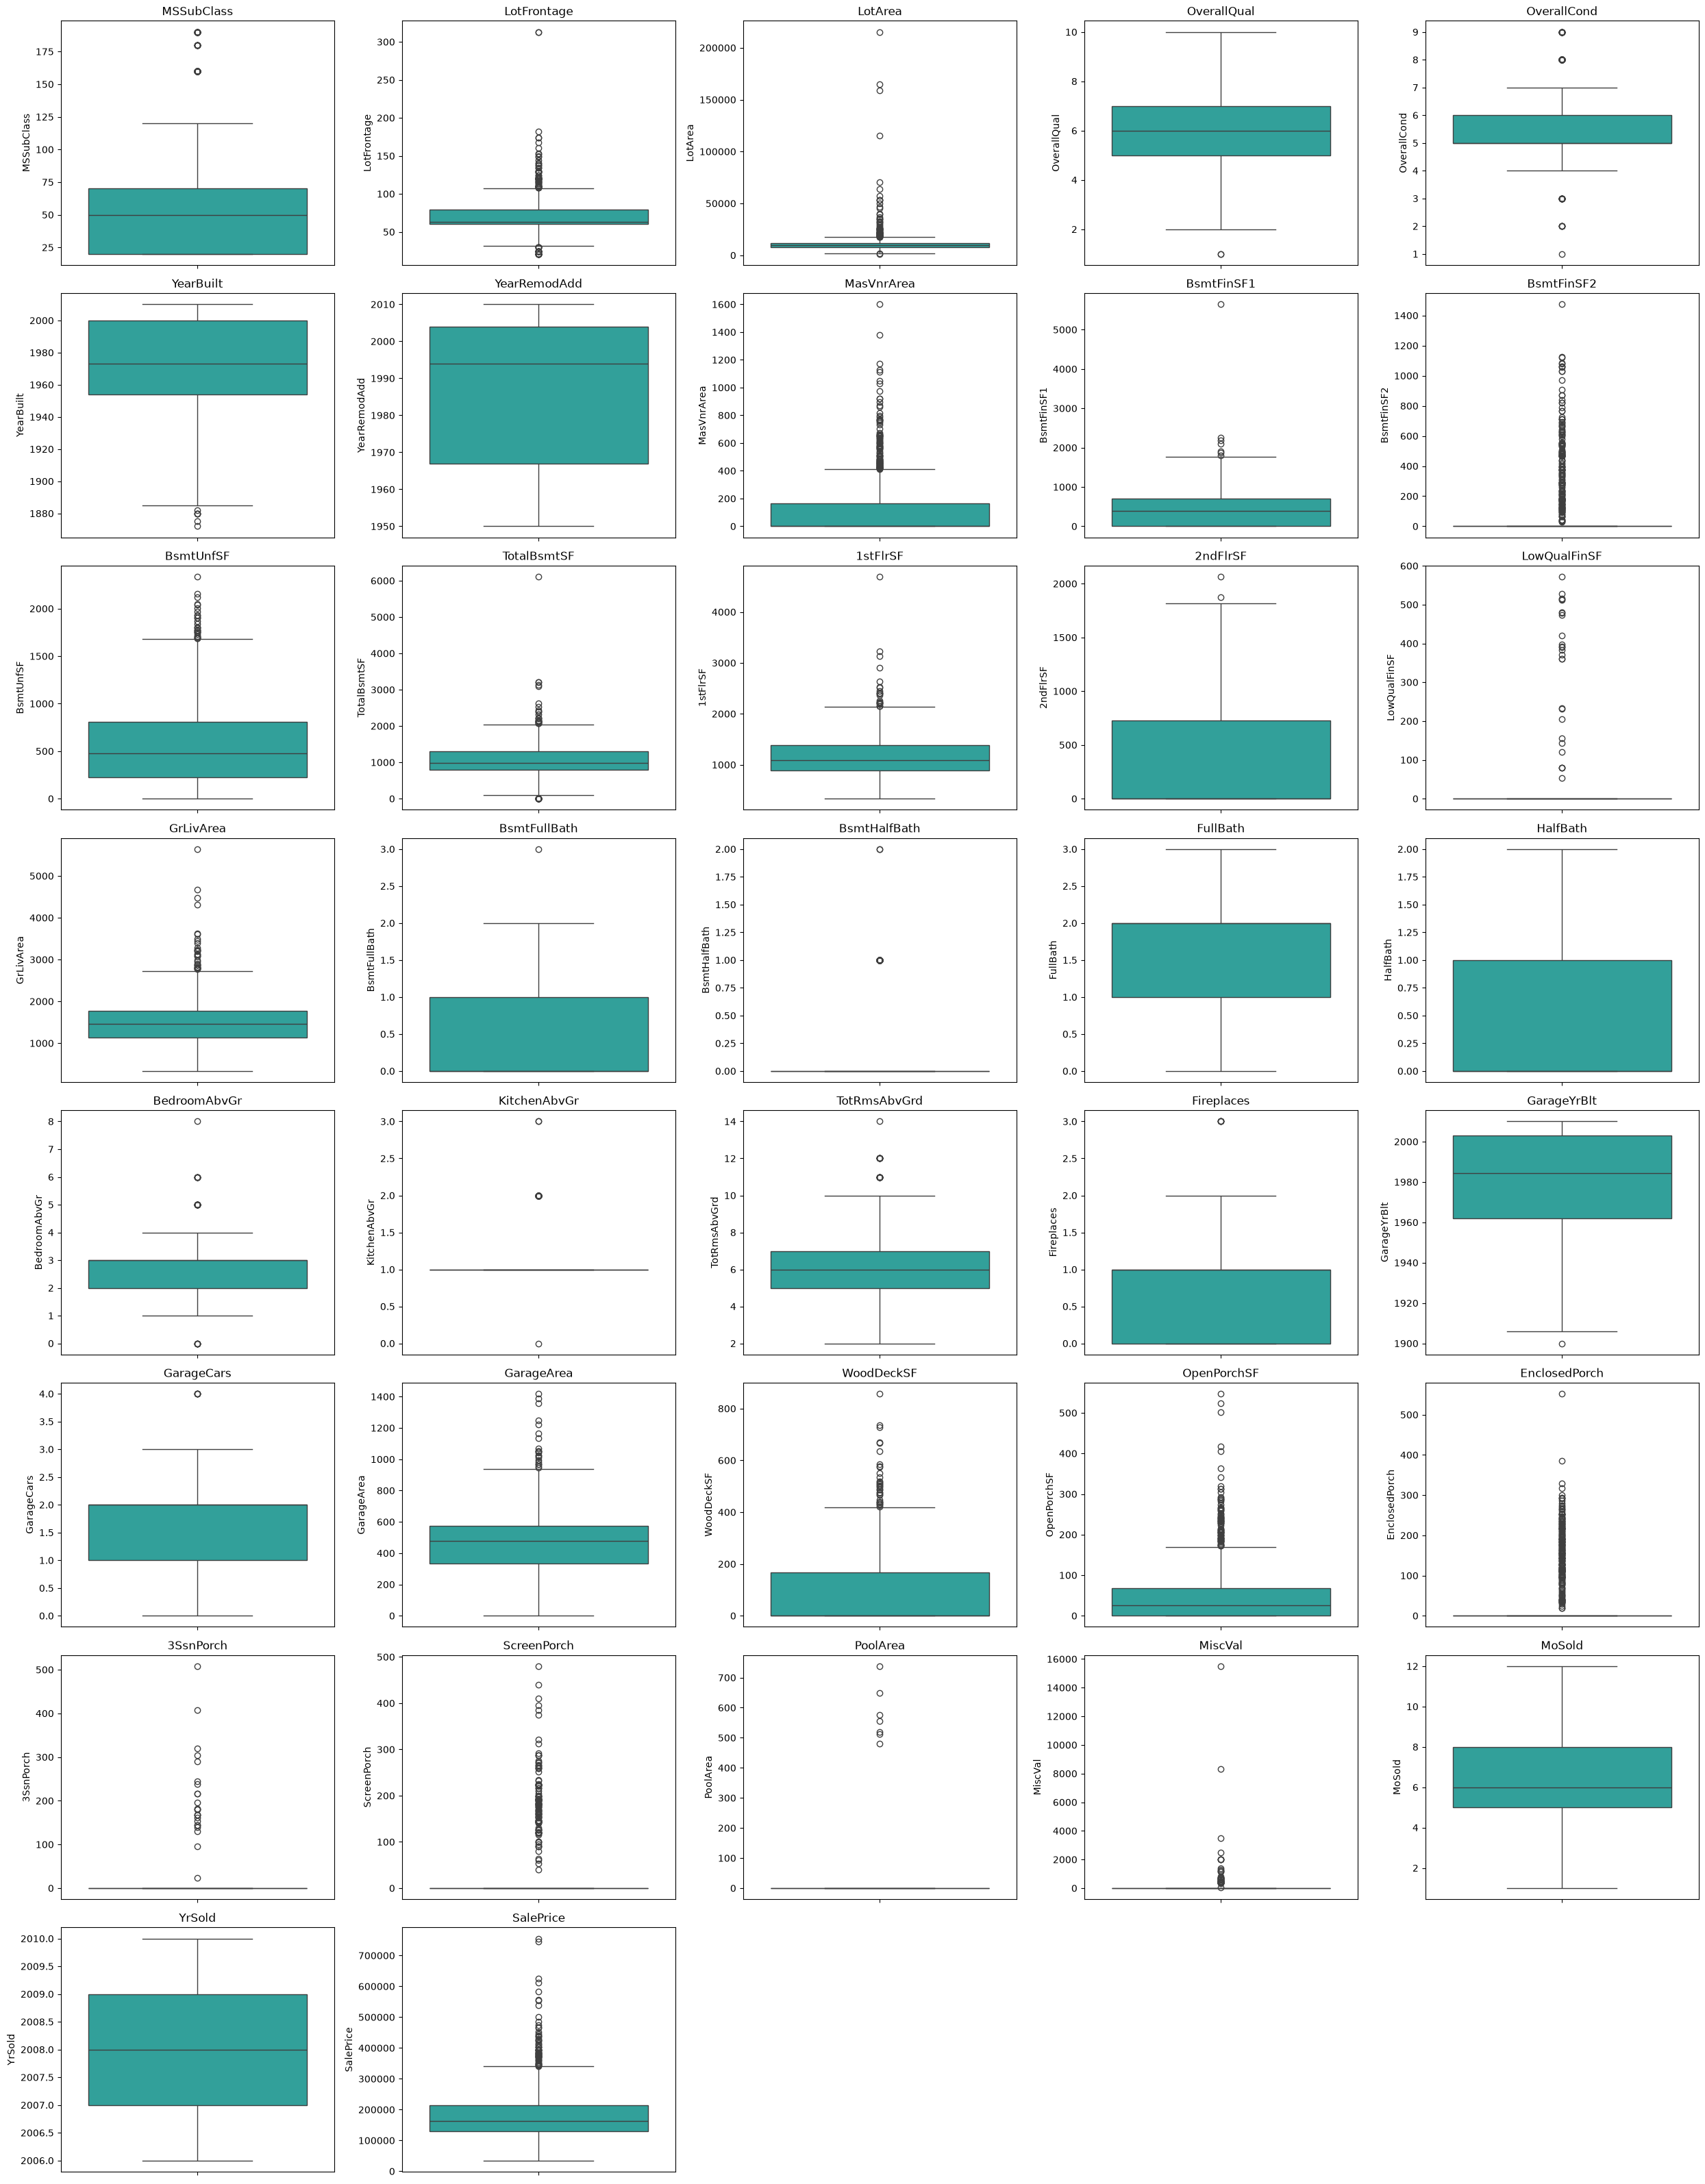

In [43]:
num_cols_all = num_data.columns.tolist()
ncols_bp     = 5
nrows_bp     = -(-len(num_cols_all) // ncols_bp)  # pembulatan ke atas

fig, ax = plt.subplots(nrows=nrows_bp, ncols=ncols_bp, figsize=(25, nrows_bp * 4))
ax = ax.flatten()

for i, col in enumerate(num_cols_all):
    sns.boxplot(y=data[col], ax=ax[i], color="lightseagreen")
    ax[i].set_title(col)

for j in range(len(num_cols_all), len(ax)):
    ax[j].axis("off")

plt.tight_layout()
plt.show()

### Menghapus Outlier dengan Metode IQR

Metode IQR (Interquartile Range) diterapkan hanya pada atribut numerik yang benar-benar bersifat kontinu (luas area, harga, dsb). Atribut seperti tahun (`YearBuilt`, `GarageYrBlt`), atribut ordinal (`OverallQual`, `OverallCond`), atribut diskrit berjumlah kecil (`FullBath`, `Fireplaces`, dsb.), maupun atribut yang sebagian besar bernilai 0 dengan sedikit nilai bukan-nol (`PoolArea`, `MiscVal`, `ScreenPorch`, dsb.) sengaja dikecualikan, karena IQR akan salah menandai hampir seluruh nilai bukan-nol pada atribut semacam itu sebagai outlier sehingga data yang valid ikut terhapus.

Gunakan variabel `remove_outliers` untuk memilih apakah outlier akan dihapus atau tidak.

Ukuran data sebelum penghapusan outlier: (1460, 75)
  LotFrontage    :  106 baris ditandai sebagai outlier
  LotArea        :   69 baris ditandai sebagai outlier
  MasVnrArea     :   98 baris ditandai sebagai outlier
  BsmtFinSF1     :    7 baris ditandai sebagai outlier
  BsmtUnfSF      :   29 baris ditandai sebagai outlier
  TotalBsmtSF    :   61 baris ditandai sebagai outlier
  1stFlrSF       :   20 baris ditandai sebagai outlier
  2ndFlrSF       :    2 baris ditandai sebagai outlier
  GrLivArea      :   31 baris ditandai sebagai outlier
  GarageArea     :   21 baris ditandai sebagai outlier
  SalePrice      :   61 baris ditandai sebagai outlier

Ukuran data setelah penghapusan outlier: (1128, 75)


array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroo

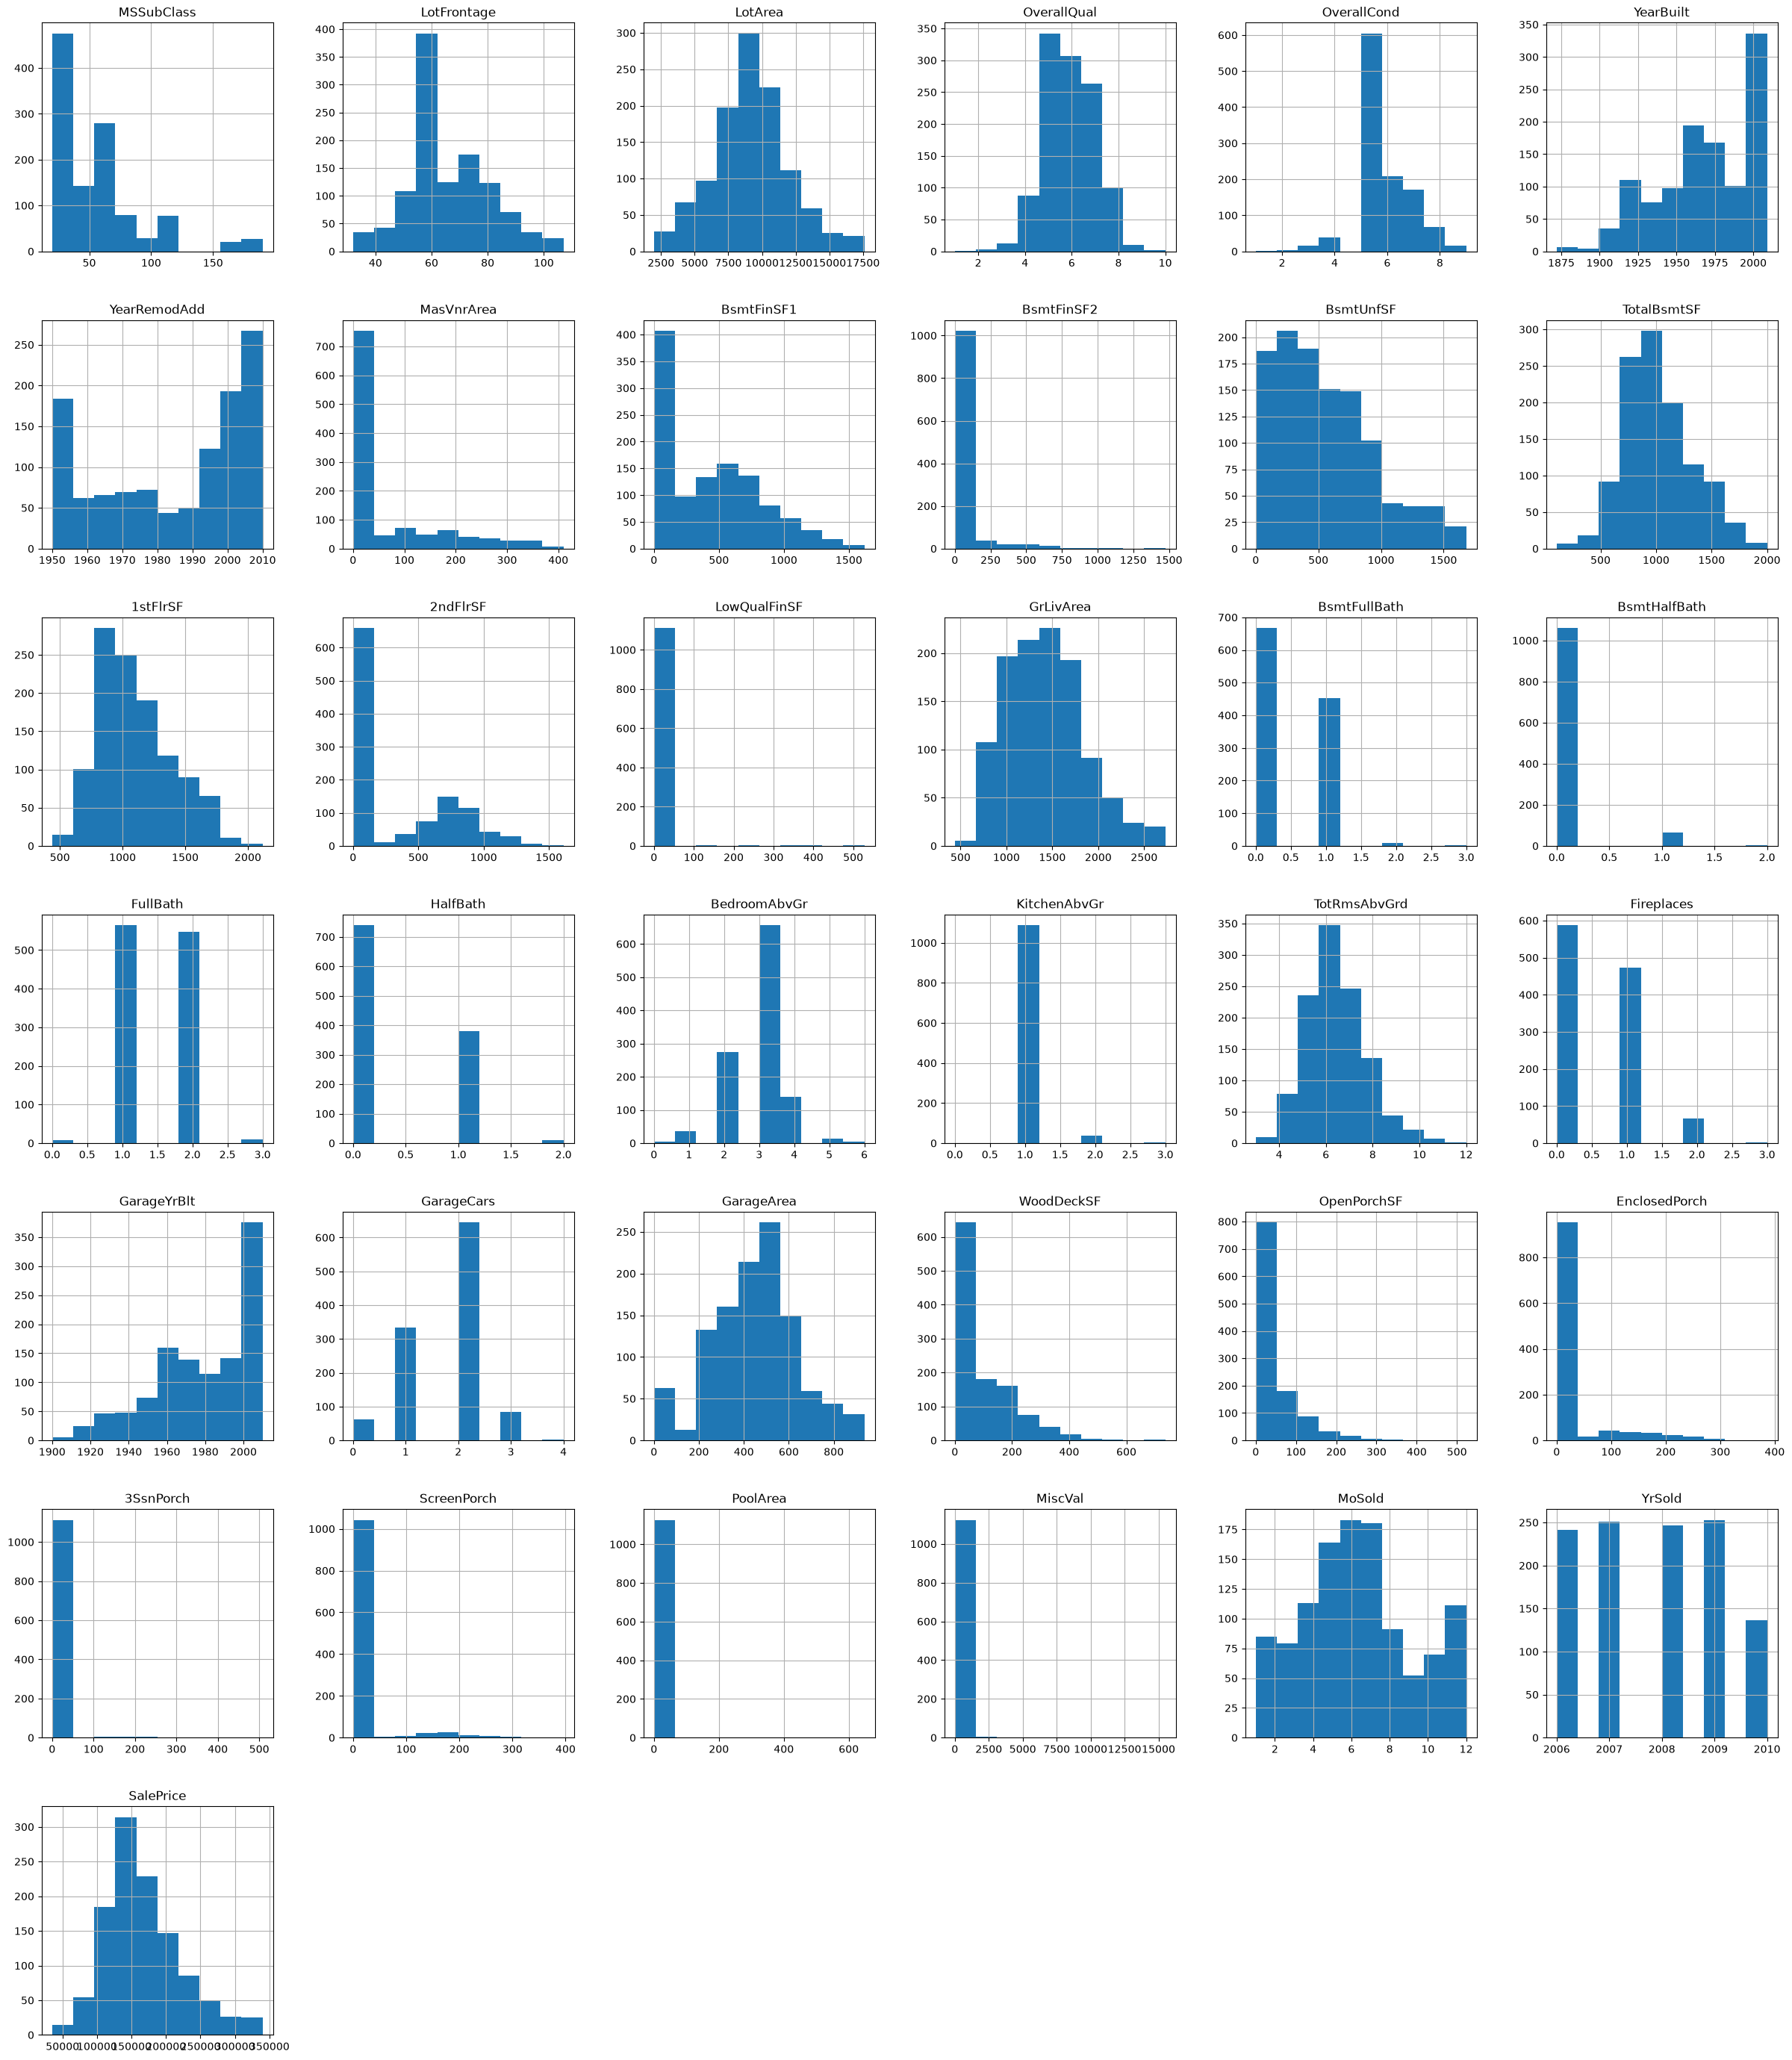

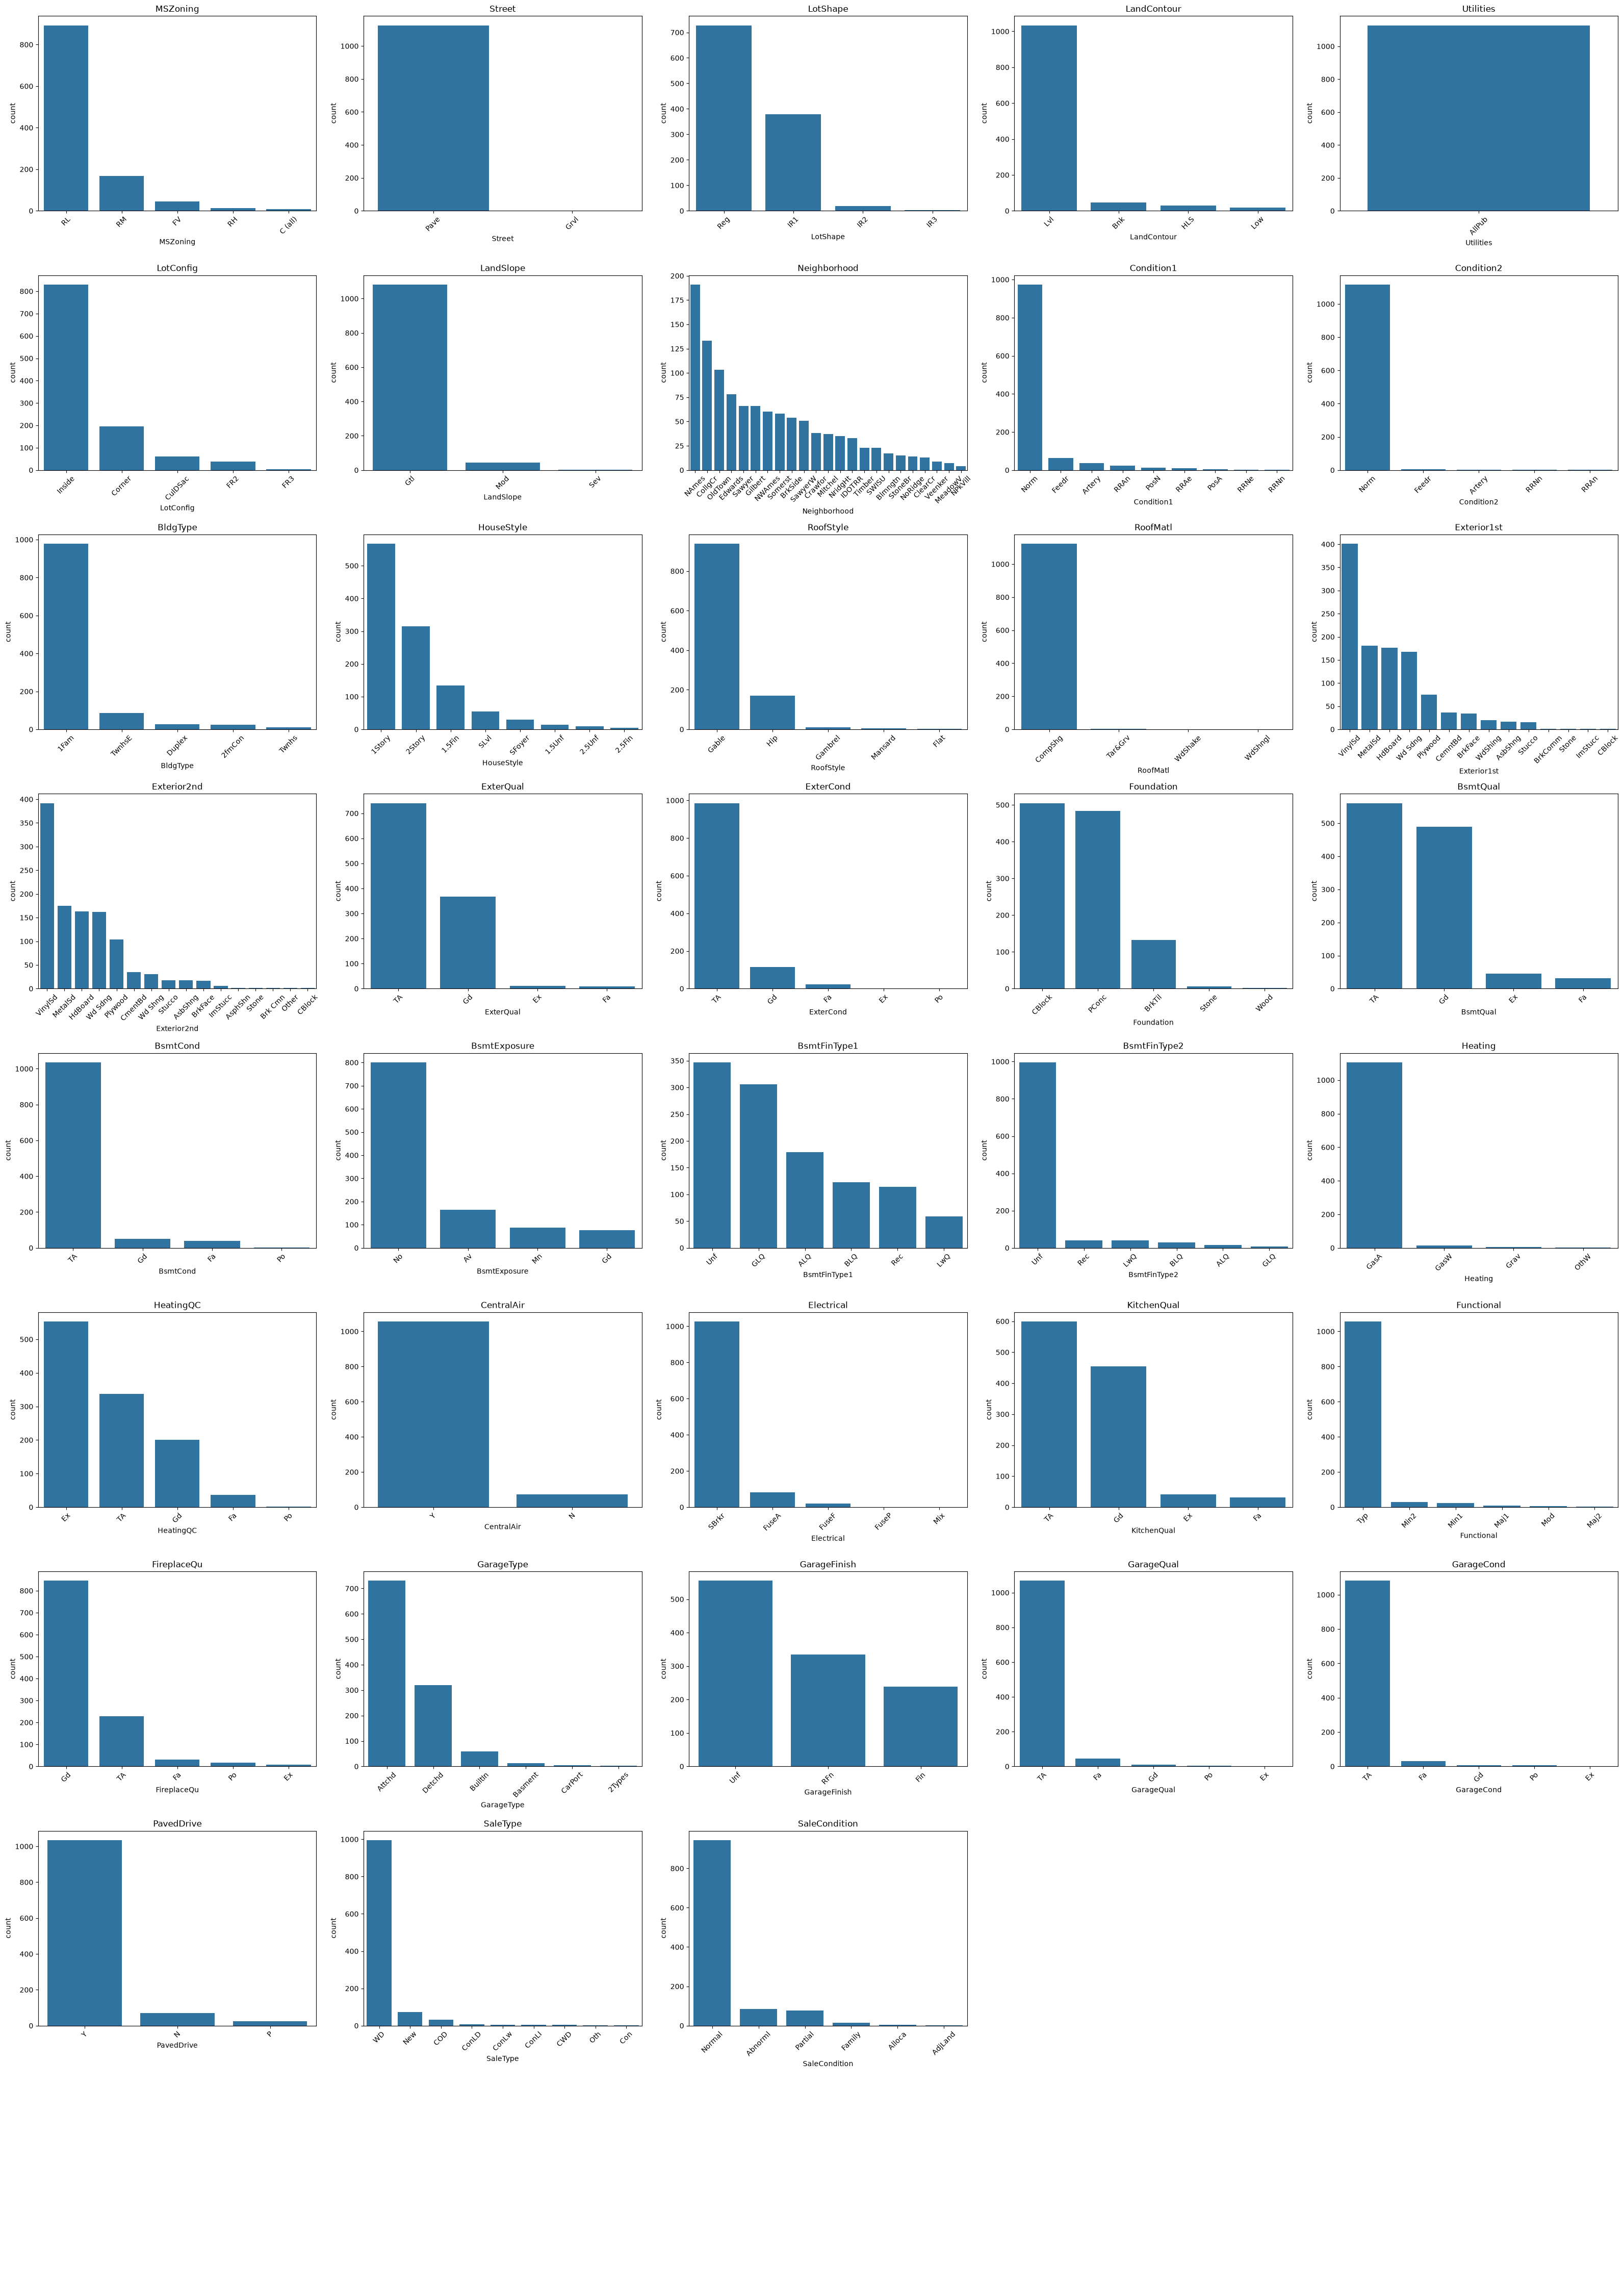

In [44]:
outlier_cols = [
    "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtUnfSF",
    "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "GrLivArea", "GarageArea", "SalePrice"
]
outlier_cols = [c for c in outlier_cols if c in data.columns]

remove_outliers = True  # ganti ke False jika tidak ingin menghapus outlier
iqr_multiplier  = 1.5

def get_iqr_bounds(series, k=1.5):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR    = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

if remove_outliers:
    print(f"Ukuran data sebelum penghapusan outlier: {data.shape}")

    outlier_mask = pd.Series(True, index=data.index)
    for col in outlier_cols:
        lower, upper = get_iqr_bounds(data[col], k=iqr_multiplier)
        col_mask = data[col].between(lower, upper)
        print(f"  {col:15s}: {(~col_mask).sum():4d} baris ditandai sebagai outlier")
        outlier_mask &= col_mask

    data = data[outlier_mask].reset_index(drop=True)
    print(f"\nUkuran data setelah penghapusan outlier: {data.shape}")
else:
    print("Outlier tidak dihapus dari data.")

num_data     = data.select_dtypes(["float64", "int64"])
nominal_data = data.select_dtypes(["str"])

display(num_data.hist(figsize=(30, 35)))

nrows, ncols = 9, 5
cols         = nominal_data.columns
fig, ax      = plt.subplots(nrows=nrows, ncols=ncols, figsize=(32, 45))

for i in range(nrows):
    for j in range(ncols):
        idx = i * ncols + j
        if idx < len(cols):
            col = cols[idx]
            order = nominal_data[col].value_counts().index
            sns.countplot(data=nominal_data, x=col, order=order, ax=ax[i, j])
            ax[i, j].set_title(col)
            ax[i, j].tick_params(axis="x", rotation=45)
        else:
            ax[i, j].axis("off")

plt.tight_layout()
plt.show()

## Standarisasi / Normalisasi Fitur Numerik

`SalePrice` diperlakukan sebagai variabel target sehingga tidak ikut diskalakan. Fitur numerik lain yang skalanya sudah berada pada rentang [0, 1] juga tidak diproses ulang; hanya fitur berskala besar yang distandarisasi/dinormalisasi.

In [45]:
target_col = "SalePrice"

feature_num_cols   = [c for c in num_data.columns if c != target_col]
already_scaled_cols = [c for c in feature_num_cols if data[c].min() >= 0 and data[c].max() <= 1]
cols_to_scale       = [c for c in feature_num_cols if c not in already_scaled_cols]

print(f"Fitur numerik yang sudah bernilai [0, 1] (tidak diproses ulang): {already_scaled_cols}")
print(f"\nJumlah fitur numerik yang akan diskalakan: {len(cols_to_scale)}")

Fitur numerik yang sudah bernilai [0, 1] (tidak diproses ulang): []

Jumlah fitur numerik yang akan diskalakan: 36


In [46]:
scaling_method = "standard"  # pilihan: "standard" (StandardScaler) atau "minmax" (Normalisasi MinMaxScaler)

if scaling_method == "standard":
    scaler = StandardScaler()
elif scaling_method == "minmax":
    scaler = MinMaxScaler()
else:
    raise ValueError('scaling_method harus "standard" atau "minmax"')

data[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])

print(f"Fitur numerik telah diskalakan menggunakan {scaler.__class__.__name__}.")
display(data[cols_to_scale].describe())

Fitur numerik telah diskalakan menggunakan StandardScaler.


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1.128000e+03,1.128000e+03,1.128000e+03,1.128000e+03,1.128000e+03,1.128000e+03,1.128000e+03,1.128000e+03,1.128000e+03,1.128000e+03,...,1.128000e+03,1.128000e+03,1.128000e+03,1.128000e+03,1.128000e+03,1.128000e+03,1.128000e+03,1.128000e+03,1.128000e+03,1.128000e+03
mean,-1.889741e-17,2.740125e-16,-9.684924e-17,1.496045e-17,3.141695e-16,2.451939e-15,2.598001e-15,1.574784e-18,2.362177e-17,-7.558965e-17,...,6.929052e-17,4.094440e-17,2.834612e-17,-2.362177e-17,3.149569e-18,-5.039310e-17,6.299138e-18,1.417306e-17,-1.338567e-16,1.951473e-14
std,1.000444e+00,1.000444e+00,1.000444e+00,1.000444e+00,1.000444e+00,1.000444e+00,1.000444e+00,1.000444e+00,1.000444e+00,1.000444e+00,...,1.000444e+00,1.000444e+00,1.000444e+00,1.000444e+00,1.000444e+00,1.000444e+00,1.000444e+00,1.000444e+00,1.000444e+00,1.000444e+00
min,-8.802855e-01,-2.397977e+00,-2.550739e+00,-4.069108e+00,-4.113195e+00,-3.144023e+00,-1.637400e+00,-6.130061e-01,-1.070374e+00,-2.890763e-01,...,-2.319034e+00,-7.550981e-01,-6.984857e-01,-3.943839e-01,-1.056006e-01,-2.663196e-01,-4.207212e-02,-7.729067e-02,-1.962074e+00,-1.372590e+00
25%,-8.802855e-01,-4.170258e-01,-5.968965e-01,-7.723194e-01,-5.741531e-01,-6.147532e-01,-9.173082e-01,-6.130061e-01,-1.070374e+00,-2.890763e-01,...,-7.136172e-01,-7.550981e-01,-6.984857e-01,-3.943839e-01,-1.056006e-01,-2.663196e-01,-4.207212e-02,-7.729067e-02,-4.949082e-01,-6.165932e-01
50%,-1.033199e-01,-4.170258e-01,-3.100343e-02,5.187765e-02,-5.741531e-01,6.620419e-02,4.268628e-01,-6.130061e-01,-8.697031e-02,-2.890763e-01,...,7.866646e-02,-7.550981e-01,-3.652756e-01,-3.943839e-01,-1.056006e-01,-2.663196e-01,-4.207212e-02,-7.729067e-02,-1.281168e-01,1.394037e-01
75%,4.146572e-01,6.441979e-01,5.698933e-01,8.760747e-01,3.106074e-01,9.822540e-01,9.069239e-01,4.623143e-01,6.841512e-01,-2.890763e-01,...,6.207553e-01,6.292573e-01,3.344655e-01,-3.943839e-01,-1.056006e-01,-2.663196e-01,-4.207212e-02,-7.729067e-02,6.054659e-01,8.954005e-01
max,3.522520e+00,2.908142e+00,2.974187e+00,3.348666e+00,2.964889e+00,1.298413e+00,1.242967e+00,3.469229e+00,3.070408e+00,9.149656e+00,...,2.559765e+00,5.612937e+00,8.014958e+00,5.793426e+00,1.764497e+01,7.535475e+00,2.508241e+01,3.180620e+01,2.072631e+00,1.651397e+00


## One-Hot Encoding Fitur Kategorikal

Jumlah fitur kategorikal sebelum encoding : 38
Jumlah kolom pada data sebelum encoding    : 75
Jumlah kolom pada data setelah encoding    : 218
(1128, 38)


array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>],
       [<Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'BedroomA

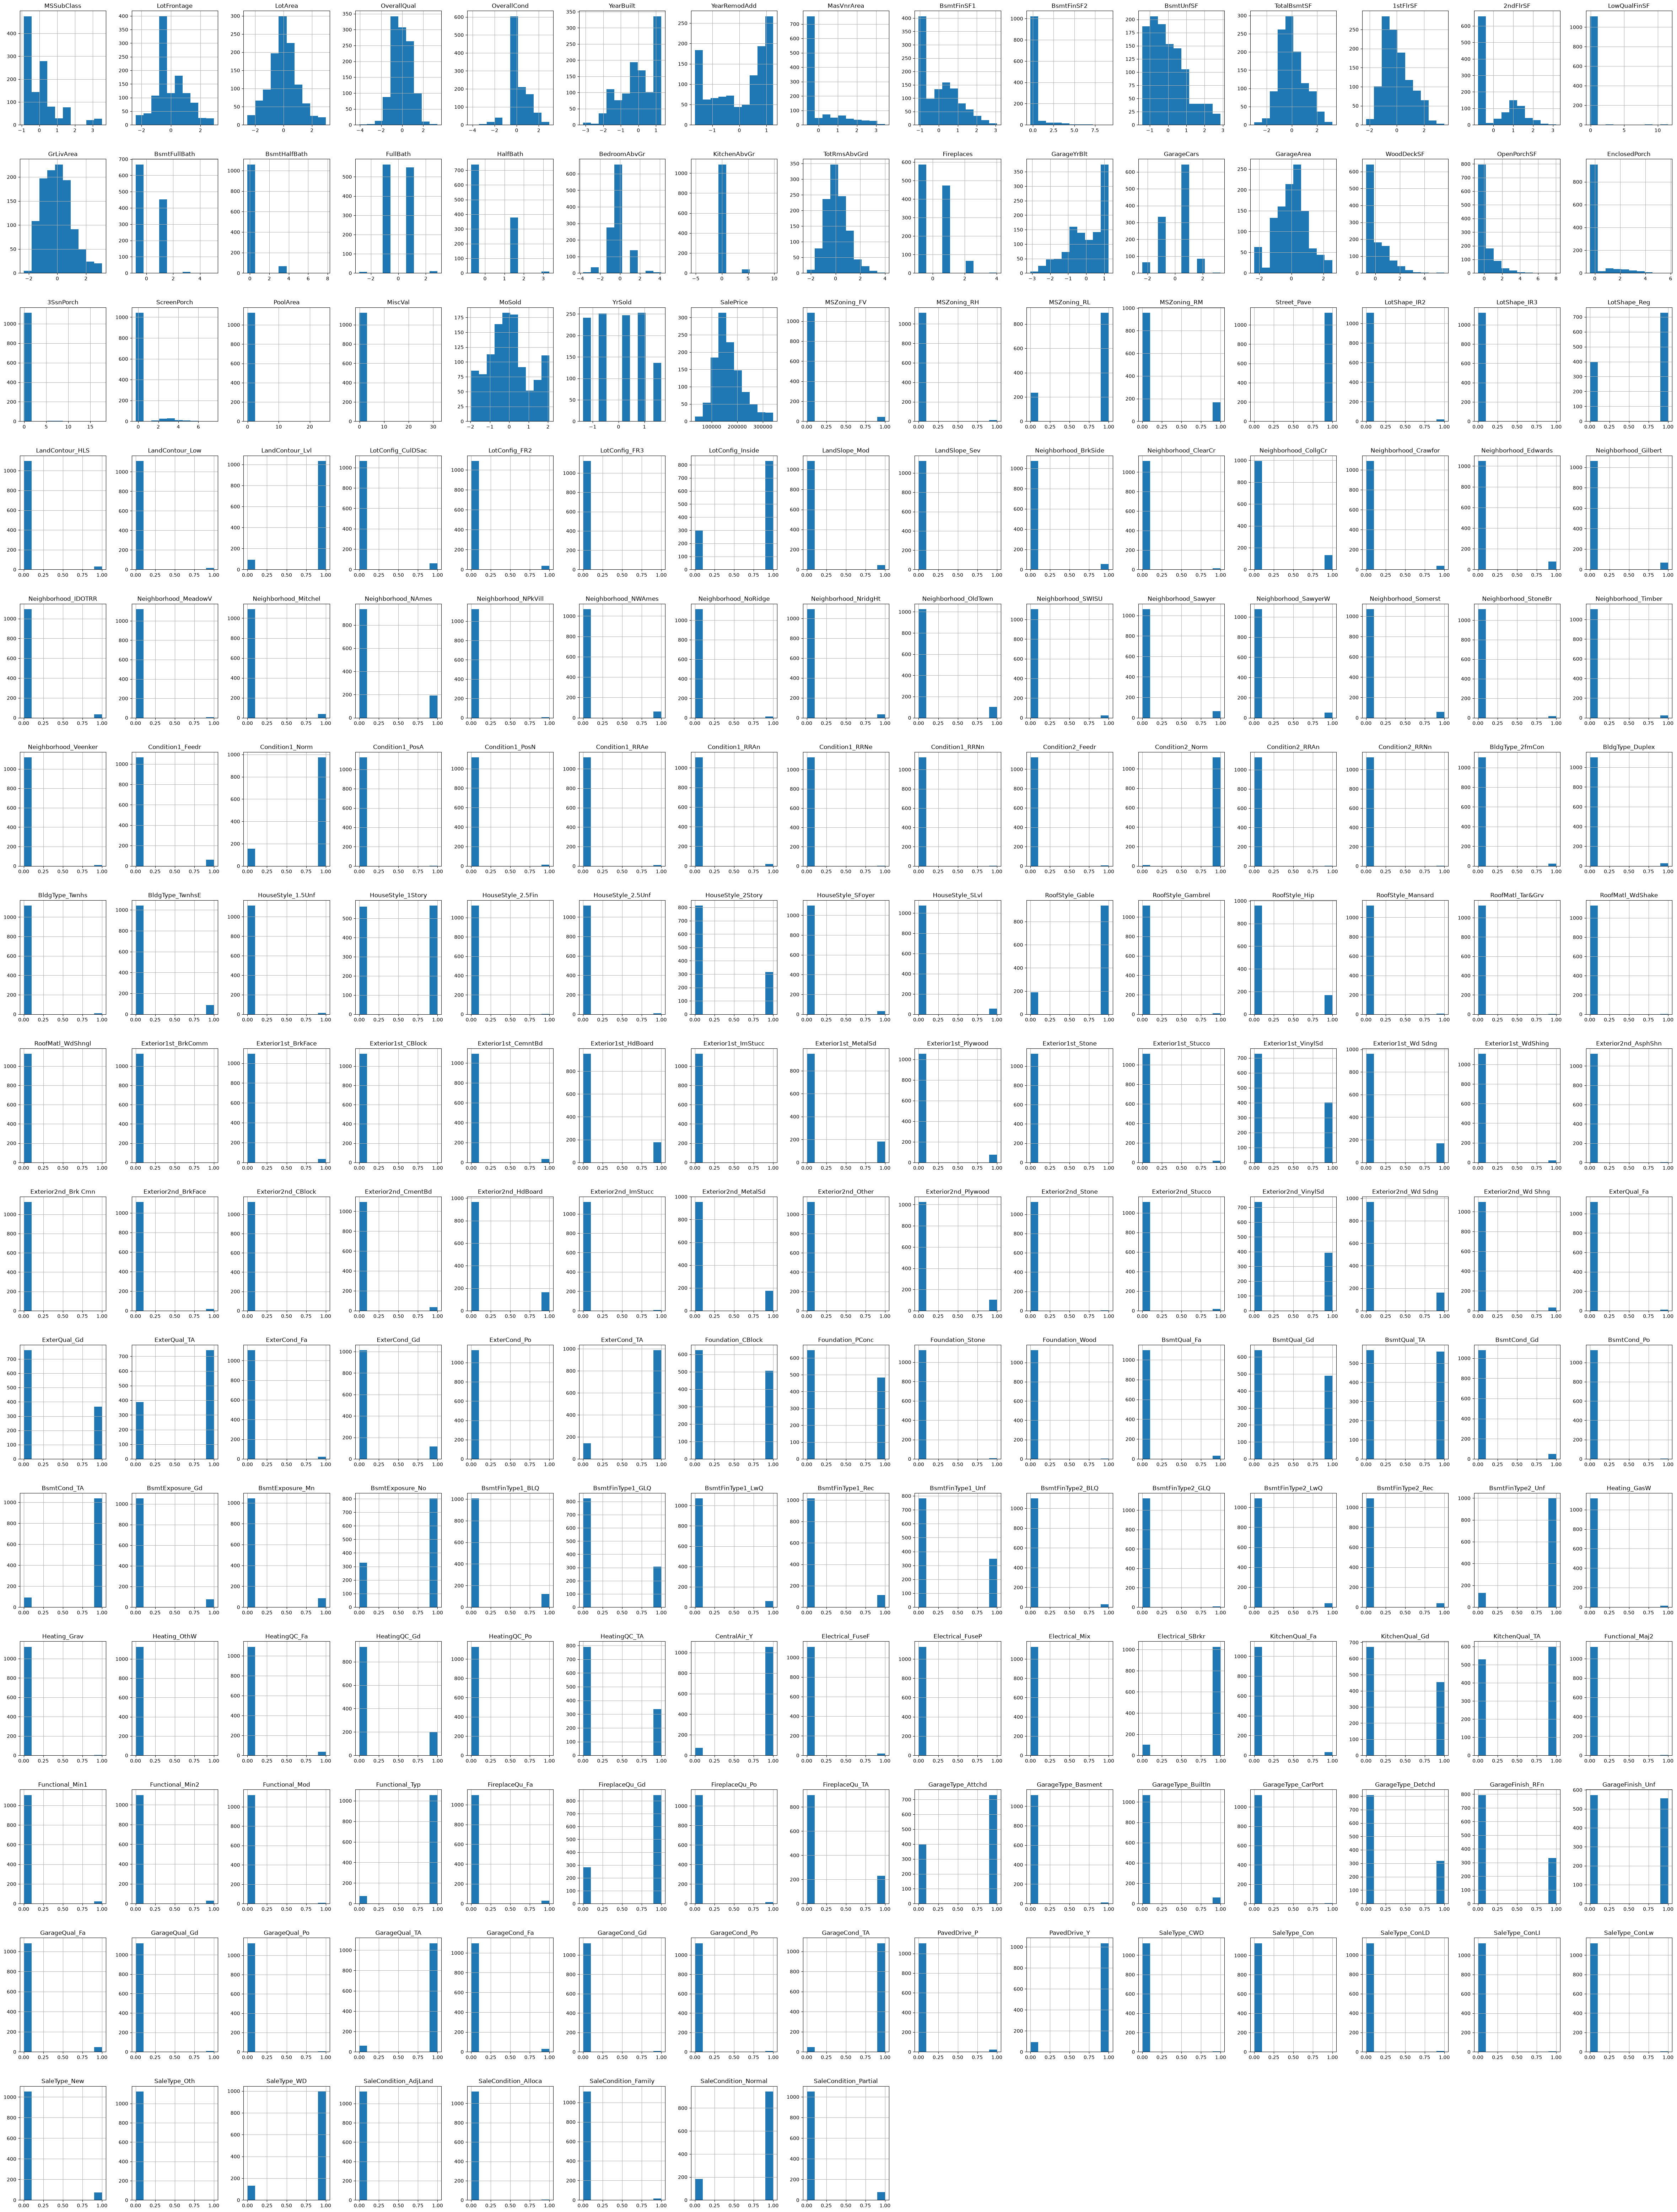

In [47]:
nominal_data = data.select_dtypes(["str"])

print(f"Jumlah fitur kategorikal sebelum encoding : {nominal_data.shape[1]}")
print(f"Jumlah kolom pada data sebelum encoding    : {data.shape[1]}")

data = pd.get_dummies(data, columns=nominal_data.columns.tolist(), drop_first=True, dtype=int)

print(f"Jumlah kolom pada data setelah encoding    : {data.shape[1]}")
data.head()

print(nominal_data.shape)

display(data.hist(figsize=(60, 80)))

## Analisis Korelasi Antar Fitur

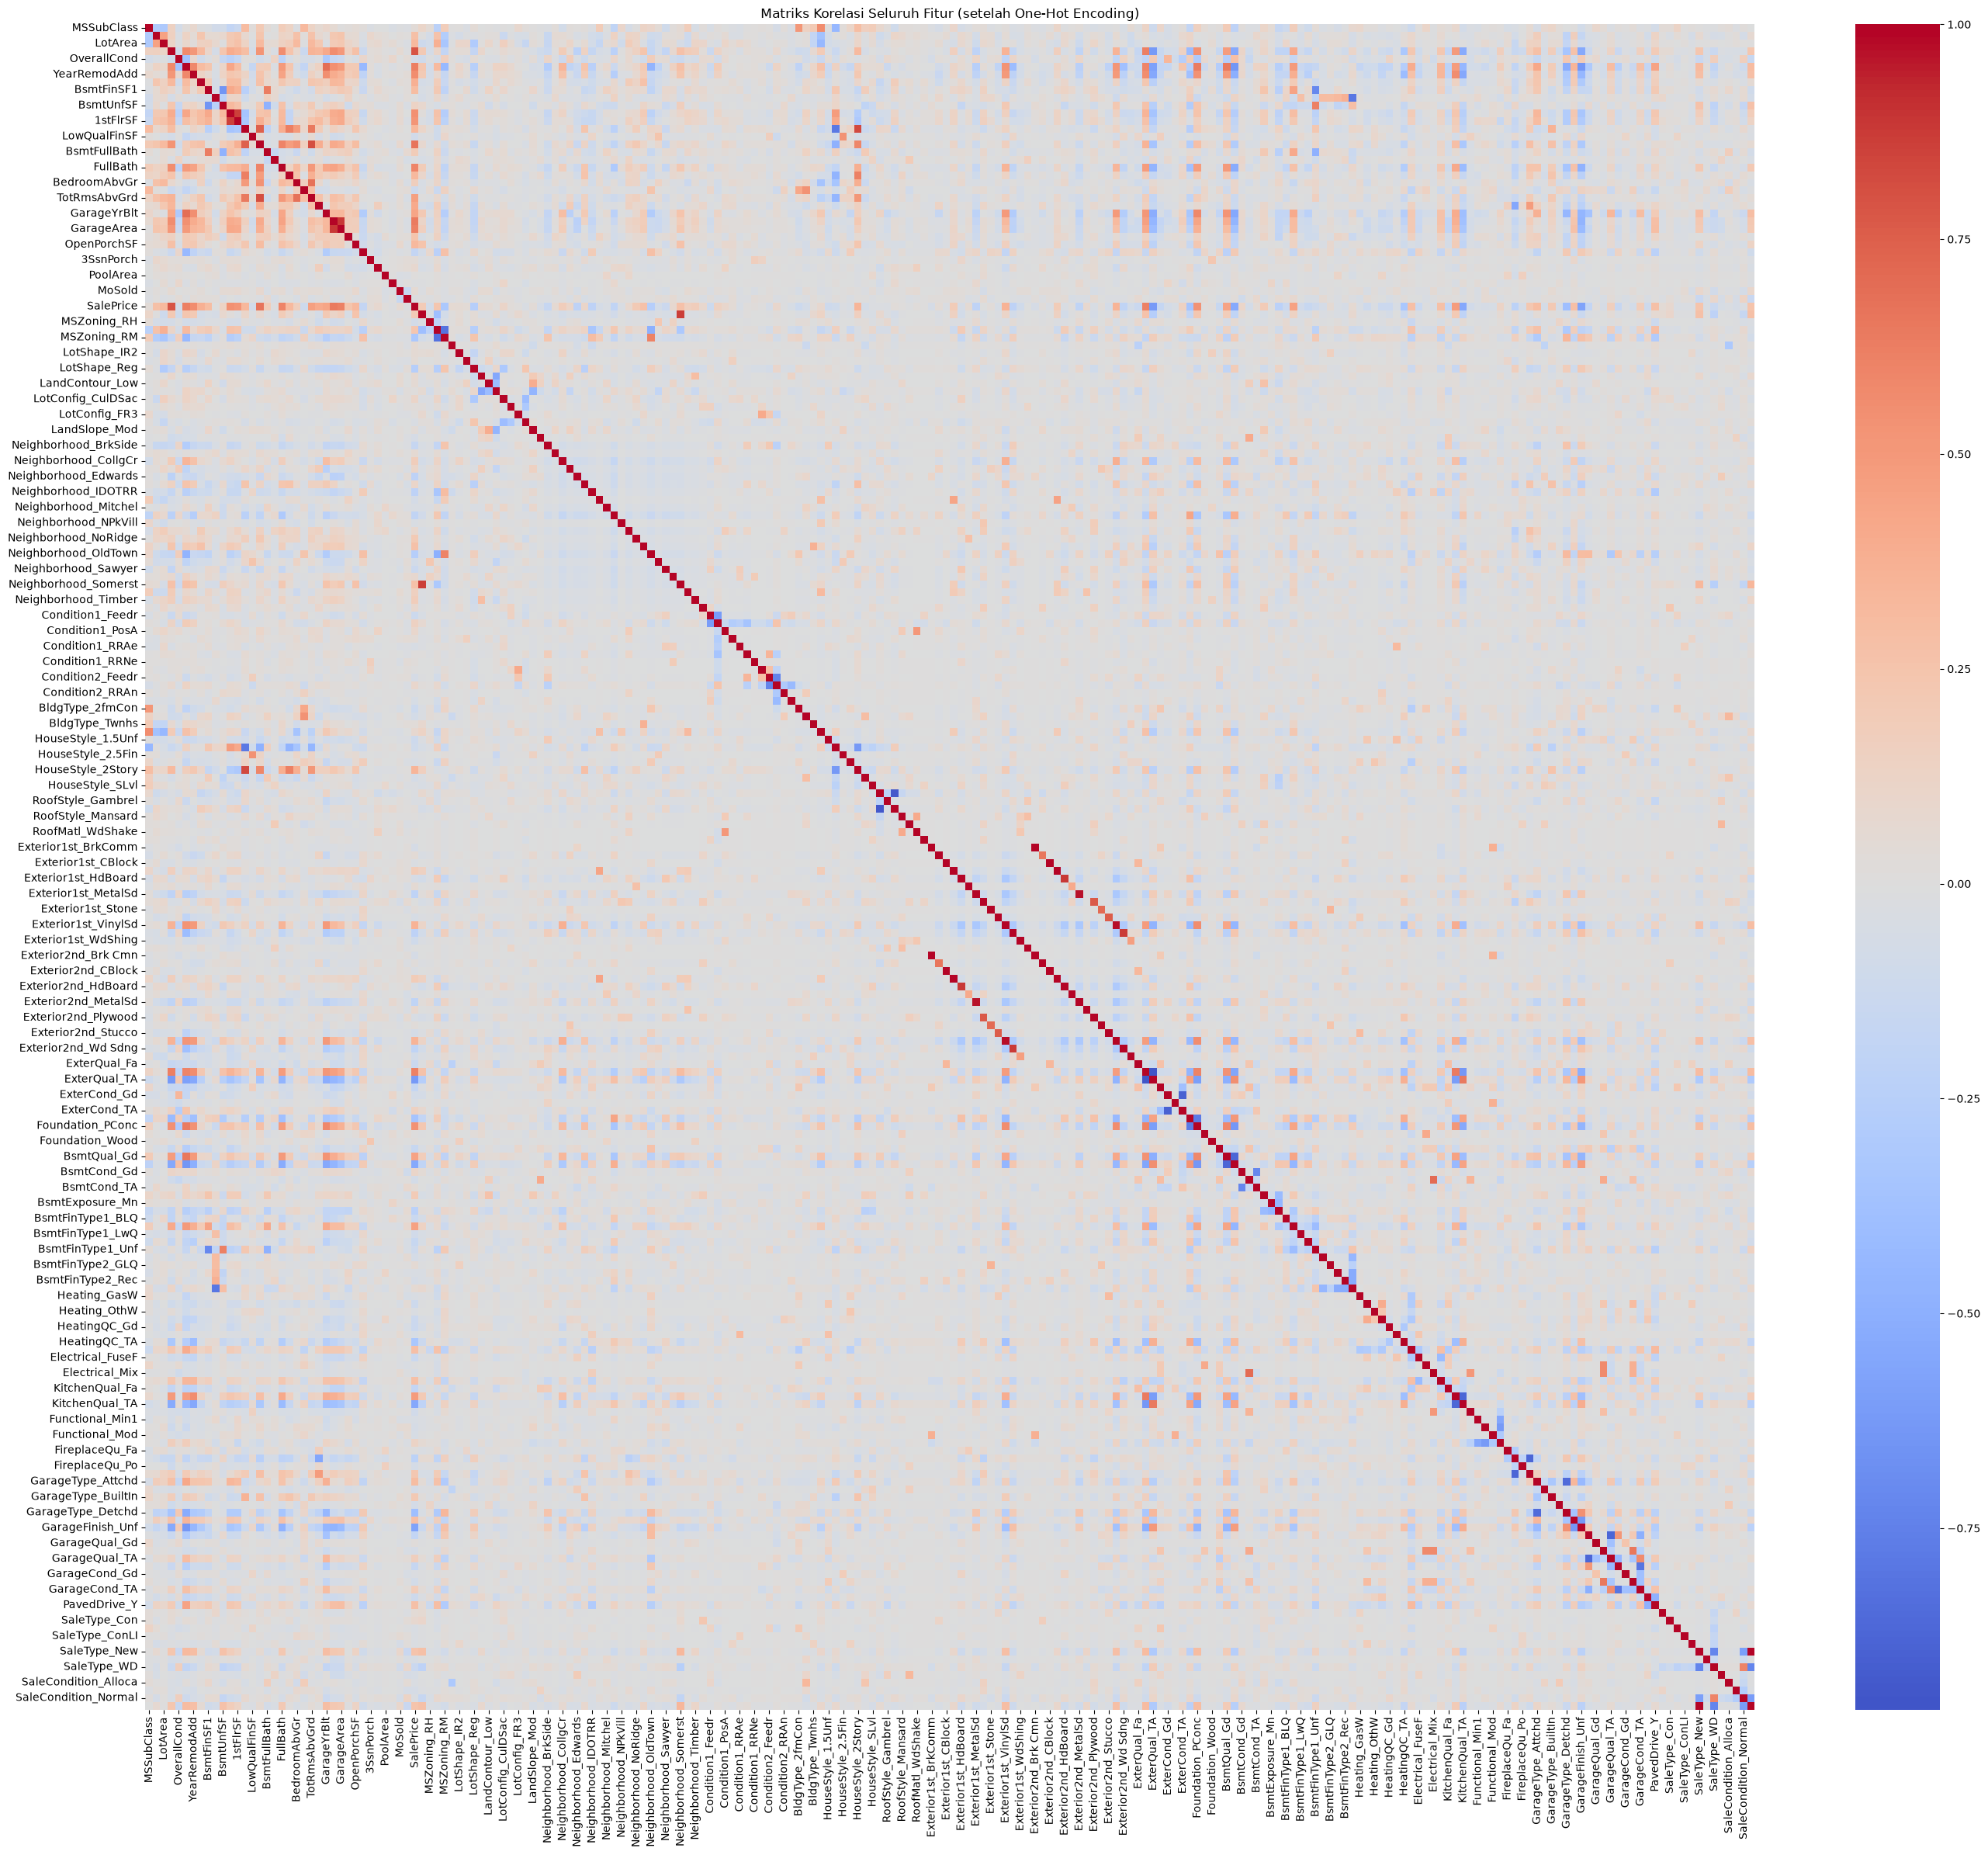

In [48]:
corr_matrix = data.corr()

plt.figure(figsize=(28, 24))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, cbar=True)
plt.title("Matriks Korelasi Seluruh Fitur (setelah One-Hot Encoding)")
plt.tight_layout()
plt.show()

### Membuang Fitur dengan Korelasi Antar-Fitur Tinggi

Korelasi yang diperiksa di sini adalah korelasi **antar fitur prediktor** (bukan dengan `SalePrice`), karena dua fitur yang berkorelasi sangat tinggi cenderung membawa informasi yang sama (redundan/multikolinearitas). Ambang batas dapat diatur melalui `correlation_threshold`, dan penghapusan dapat dimatikan melalui `drop_high_corr`.

In [49]:
correlation_threshold = 0.85
drop_high_corr        = True  # ganti ke False jika tidak ingin membuang fitur berkorelasi tinggi

feature_corr    = corr_matrix.drop(index=target_col, columns=target_col)
upper_triangle  = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
high_corr_cols  = [c for c in upper_triangle.columns if (upper_triangle[c].abs() > correlation_threshold).any()]

print(f"Jumlah fitur dengan korelasi antar-fitur > {correlation_threshold}: {len(high_corr_cols)}")
print(high_corr_cols)

if drop_high_corr and high_corr_cols:
    print(f"\nUkuran data sebelum penghapusan: {data.shape}")
    data = data.drop(columns=high_corr_cols)
    print(f"Ukuran data setelah penghapusan : {data.shape}")
else:
    print("\nFitur berkorelasi tinggi tidak dihapus.")

Jumlah fitur dengan korelasi antar-fitur > 0.85: 19
['1stFlrSF', 'GarageArea', 'Neighborhood_Somerst', 'RoofStyle_Hip', 'Exterior2nd_Brk Cmn', 'Exterior2nd_CBlock', 'Exterior2nd_CmentBd', 'Exterior2nd_HdBoard', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'Exterior2nd_Wd Sdng', 'ExterQual_TA', 'ExterCond_TA', 'BsmtQual_TA', 'KitchenQual_TA', 'FireplaceQu_TA', 'GarageType_Detchd', 'GarageQual_TA', 'SaleCondition_Partial']

Ukuran data sebelum penghapusan: (1128, 218)
Ukuran data setelah penghapusan : (1128, 199)


## Reduksi Dimensi dengan PCA

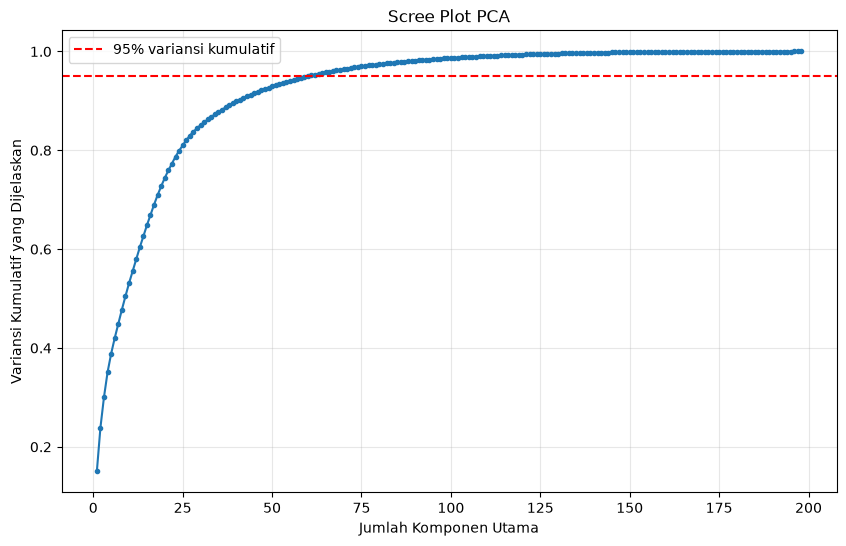

Jumlah komponen utama yang dibutuhkan untuk menjelaskan >= 95% variansi: 60


In [50]:
X = data.drop(columns=[target_col])
y = data[target_col]

pca_full = PCA()
pca_full.fit(X)

explained_var     = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_explained_var) + 1), cum_explained_var, marker="o", markersize=3)
plt.axhline(0.95, color="red", linestyle="--", label="95% variansi kumulatif")
plt.xlabel("Jumlah Komponen Utama")
plt.ylabel("Variansi Kumulatif yang Dijelaskan")
plt.title("Scree Plot PCA")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

n_components_95 = int(np.argmax(cum_explained_var >= 0.95) + 1)
print(f"Jumlah komponen utama yang dibutuhkan untuk menjelaskan >= 95% variansi: {n_components_95}")

Ukuran data sebelum PCA: (1128, 198)
Ukuran data setelah PCA: (1128, 60)
Total variansi yang dipertahankan: 0.9501


array([[<Axes: title={'center': 'PCA_feat1'}>,
        <Axes: title={'center': 'PCA_feat2'}>,
        <Axes: title={'center': 'PCA_feat3'}>,
        <Axes: title={'center': 'PCA_feat4'}>,
        <Axes: title={'center': 'PCA_feat5'}>],
       [<Axes: title={'center': 'PCA_feat6'}>,
        <Axes: title={'center': 'PCA_feat7'}>,
        <Axes: title={'center': 'PCA_feat8'}>,
        <Axes: title={'center': 'PCA_feat9'}>,
        <Axes: title={'center': 'PCA_feat10'}>],
       [<Axes: title={'center': 'PCA_feat11'}>,
        <Axes: title={'center': 'PCA_feat12'}>,
        <Axes: title={'center': 'PCA_feat13'}>,
        <Axes: title={'center': 'PCA_feat14'}>,
        <Axes: title={'center': 'PCA_feat15'}>],
       [<Axes: title={'center': 'PCA_feat16'}>,
        <Axes: title={'center': 'PCA_feat17'}>,
        <Axes: title={'center': 'PCA_feat18'}>,
        <Axes: title={'center': 'PCA_feat19'}>,
        <Axes: title={'center': 'PCA_feat20'}>],
       [<Axes: title={'center': 'PCA_feat21'}

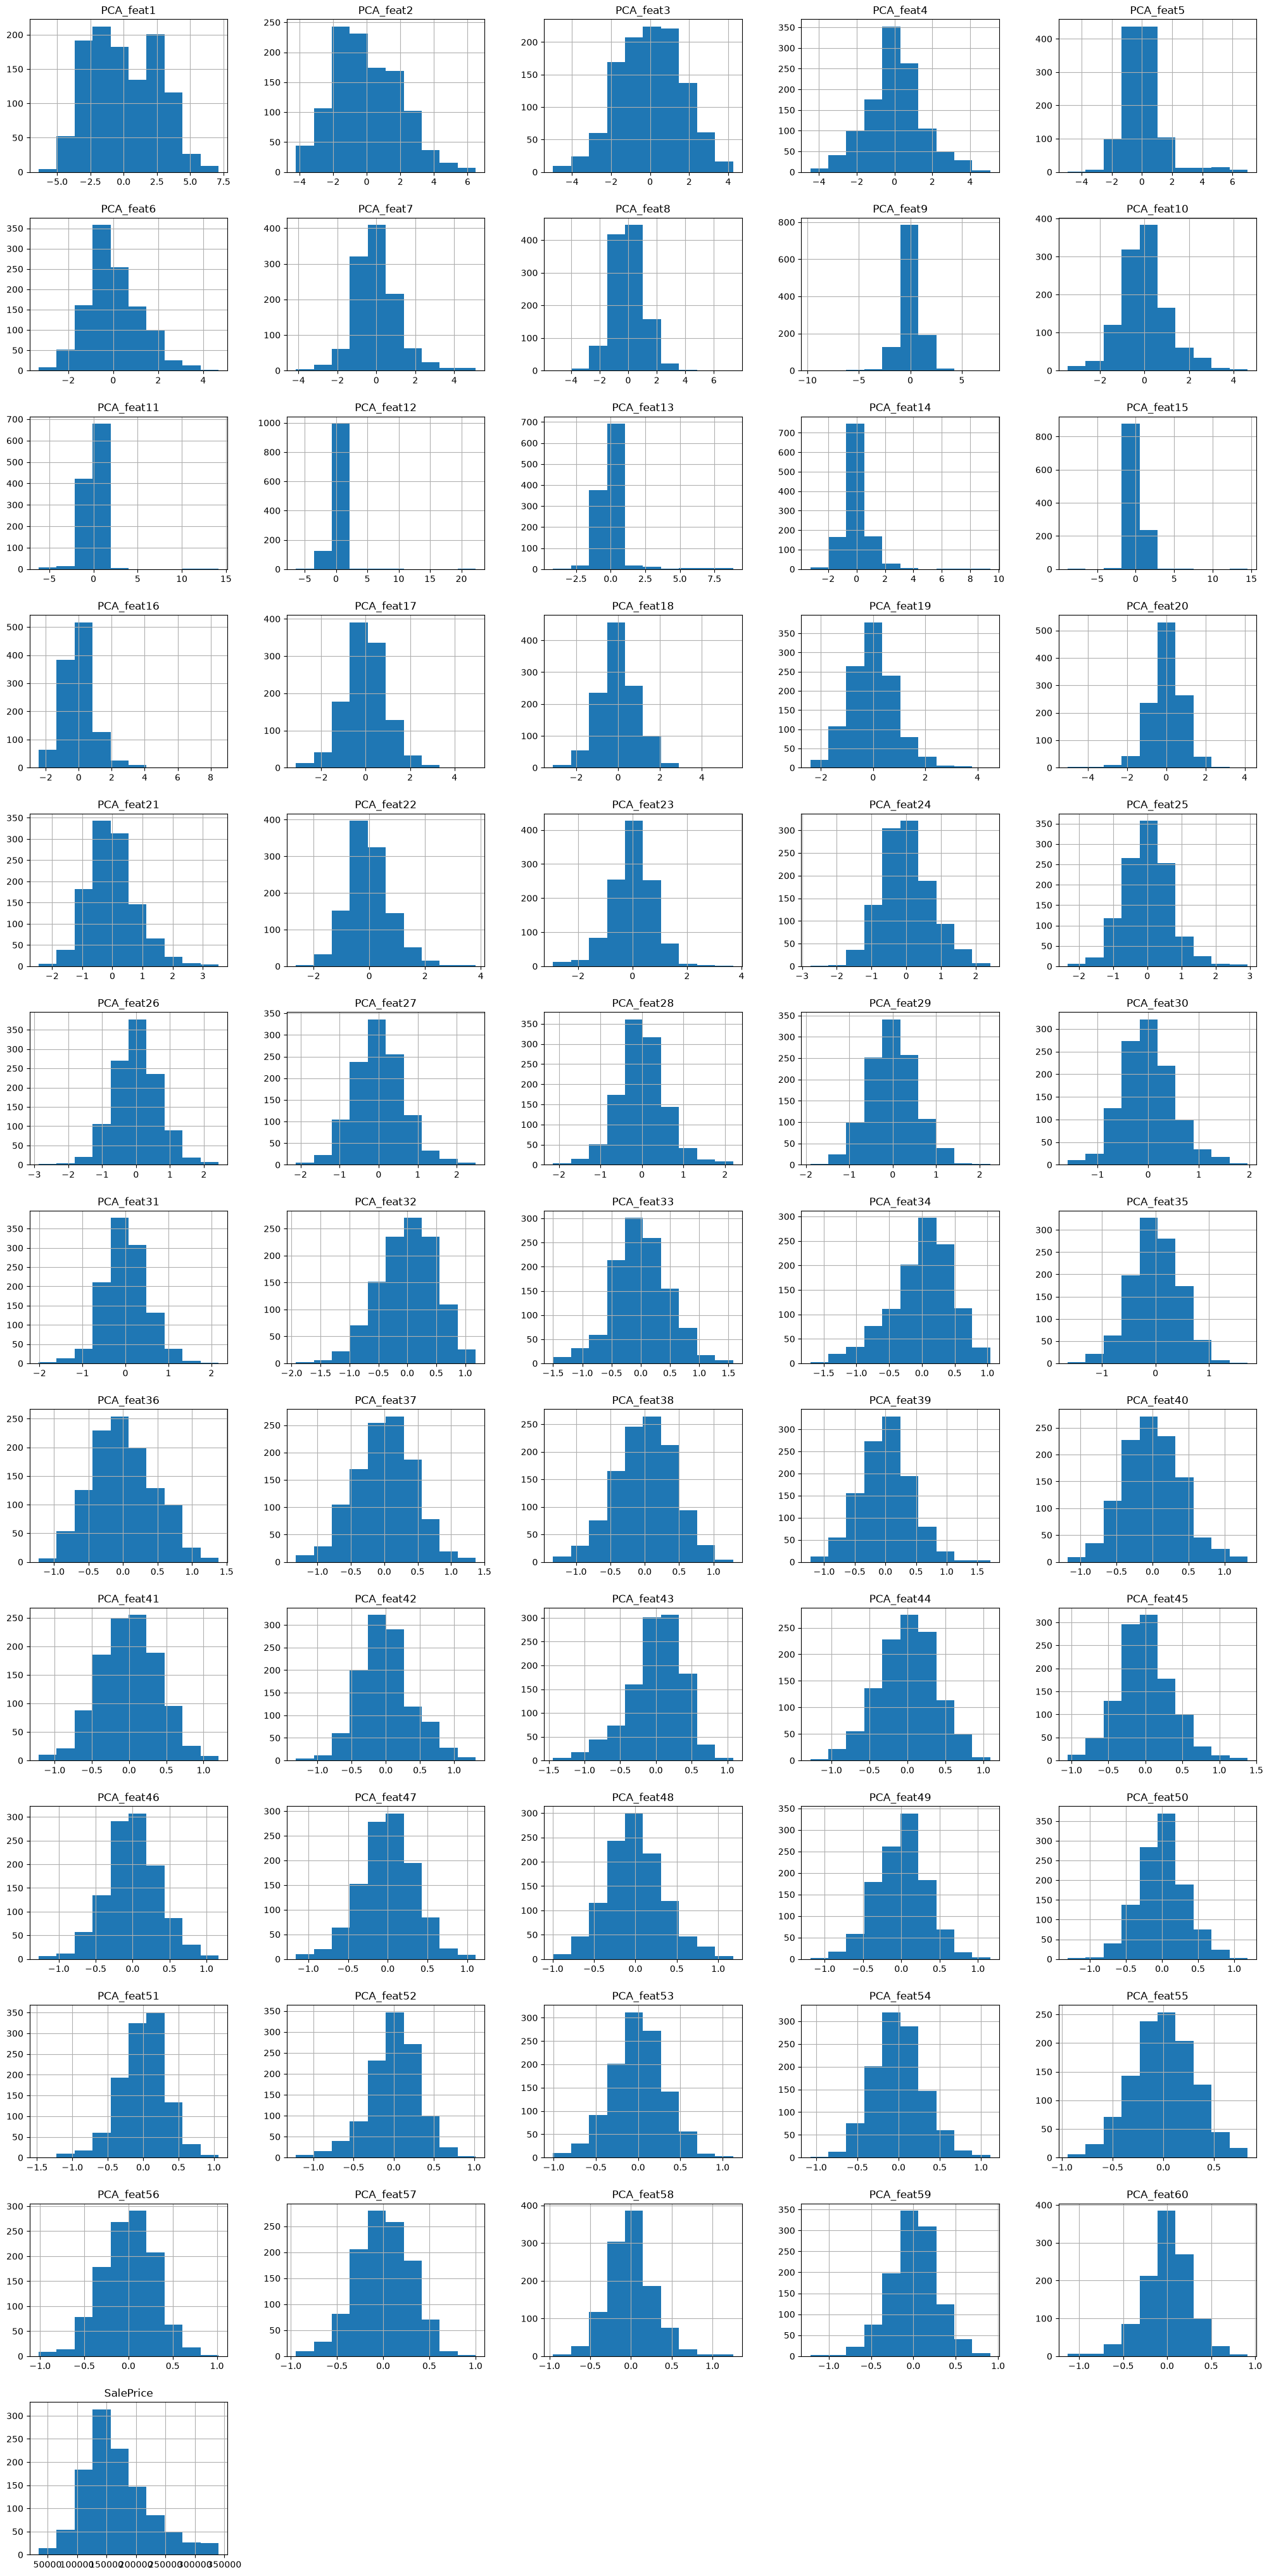

In [59]:
n_components = n_components_95  # dapat diganti manual sesuai kebutuhan

pca    = PCA(n_components=n_components)
X_pca  = pca.fit_transform(X)

data_pca = pd.DataFrame(X_pca, columns=[f"PCA_feat{i+1}" for i in range(n_components)])
data_pca[target_col] = y.values

print(f"Ukuran data sebelum PCA: {X.shape}")
print(f"Ukuran data setelah PCA: {X_pca.shape}")
print(f"Total variansi yang dipertahankan: {pca.explained_variance_ratio_.sum():.4f}")

data_pca.head()
data_pca.to_csv("5054251023_Zico Diego Rio Ramadhonny_Tugas_Praproses_Data.csv")
data_pca.hist(layout=(13, 5), figsize=(25, 52))